- Curso: PPG em Genética e Biologia Molecular (PPGBM-UFPA)
- Disciplina: IA na Descoberta Biológica
- Tema: Análise de Datasets Multiômicos
- Docente: Helder Matos e Sintia Almeida

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

from scipy import stats

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 0. Preliminares

## 0.1. Ambiente de desenvolvimento: Notebooks

Um notebook é um caderno de notas que roda no navegador. Nele, texto, código e resultados ficam no mesmo documento, o que facilita desenvolver projetos de ciência e mineração de dados e compartilhá-los com outras pessoas.

Um notebook tem pelo menos dois tipos de célula:

- a célula de **código**, que executa scripts em Python (outras linguagens também são possíveis);
- a célula de **markdown**, que guarda texto formatado para documentar e organizar o raciocínio.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/notebook.png" alt="Interface genérica de uma aplicação para Notebooks" width="800">
</div>

Esta célula, assim como todas as anteriores, é de markdown. A próxima é de código.

In [ ]:
# Esta célula atual é uma célula de código Python.

for i in range(10):
    if i % 2 == 0:
        print(f"{i} é par")
    else:
        print(f"{i} é ímpar")

0 é par
1 é ímpar
2 é par
3 é ímpar
4 é par
5 é ímpar
6 é par
7 é ímpar
8 é par
9 é ímpar


Um notebook pode rodar na máquina do próprio usuário, o que exige instalar o ambiente por Pip ou Conda. Pode também rodar na nuvem, num serviço externo que dispensa instalação, como o Google Colab, o Kaggle Kernels ou o Azure Notebooks.

Nesta aula, usaremos o **Google Colab**. Algumas células de código têm um formulário ao lado, com listas, caixas de marcação e controles deslizantes, e mudar um valor ali altera a análise sem que seja preciso editar o código.

Se o ambiente ficar inativo por muito tempo, o Colab desconecta e as variáveis carregadas se perdem. Nesse caso, basta reconectar, selecionar a célula em que você parou e executar as células anteriores pelo menu Ambiente de execução.

## 0.2. Roteiro da aula

A aula percorre as etapas do KDD sobre um dataset multiômico sintético e depois volta a elas para testar o que foi encontrado. A pergunta que orienta a análise é o que um modelo encontra nos dados e o que ele não consegue dizer sobre eles.

1. [Vídeo: Machine Learning View of Multi-Omics Data Integration](#video): trecho de uma palestra que apresenta a integração multiômica e a maldição da dimensionalidade.
2. [Knowledge Discovery in Databases (KDD)](#kdd): apresenta o processo que organiza a análise.
3. [Seleção](#selecao): carrega as tabelas de cada camada molecular e as integra numa única tabela.
4. [Pré-processamento](#pre-processamento): confere valores ausentes e lote, normaliza as contagens e compara os grupos variável por variável.
5. [Transformação](#transformacao): coloca as variáveis numa escala comum e resume o dado em duas dimensões.
6. [Mineração de dados](#mineracao): treina três classificadores e mede o acerto de cada um.
7. [Interpretação e avaliação](#avaliacao): investiga quais variáveis os modelos usaram para decidir.
8. [Retorno à seleção](#retorno-selecao): remove camadas e genes e mede o acerto de novo.
9. [Simulador](#simulador): gera dados com resposta conhecida e cria situações em que o modelo erra.
10. [Conclusão](#conclusao): responde à pergunta da aula com o que as seções anteriores mostraram.

# 1. Vídeo: Machine Learning View of Multi-Omics Data Integration <a id="video"></a>

[Assistir: Machine Learning View of Multi-Omics Data Integration (inicia em 3:24)](https://youtu.be/Jrz6t3fbOCw?t=204)

# 2. Knowledge Discovery in Databases (KDD) <a id="kdd"></a>

KDD (*Knowledge Discovery in Databases*) é o processo de descobrir padrões em dados. Os padrões procurados precisam ser válidos, novos, úteis e fazer sentido para quem olha o resultado.

O processo é interativo, porque o analista intervém em cada etapa. É também iterativo, porque volta a etapas anteriores e as refina à medida que o entendimento avança.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/kdd-process.png" alt="Processo KDD" width="100%">
</div>

A figura mostra as cinco fases do processo, e cada uma corresponde a uma seção deste notebook:

1. Seleção (seção 3): escolher quais dados e variáveis entram na análise.
2. Pré-processamento (seção 4): limpar ruído e tratar dados ausentes.
3. Transformação (seção 5): formatar e armazenar os dados do jeito que a ferramenta de mineração espera.
4. Mineração de dados (seção 6): buscar os padrões propriamente ditos.
5. Interpretação e avaliação (seção 7): visualizar os padrões encontrados e verificar se eles trazem algo útil.

As seções 8 e 9 voltam a fases anteriores com base no que as primeiras seções mostraram.

# 3. Seleção <a id="selecao"></a>

## 3.1. Carregamento dos dados

O dataset desta aula é sintético e foi montado para ensino. Ele reúne 12 amostras de pessoas: 6 controles e 6 do grupo `Deficient`, em que o produto de um complexo proteico formado por GENA, GENB e GENC está reduzido. Além desses três genes, as tabelas medem GEND, que fica fora do complexo, e HK1 e HK2, dois genes housekeeping, de expressão estável, usados como referência.

Cada camada molecular vem numa tabela, com uma linha por amostra:

- ATAC: contagem de leituras (*reads*) de sequenciamento no promotor de cada gene, que indica o quanto a cromatina ali está aberta;
- RNA: contagem de leituras de RNA atribuídas a cada gene;
- proteômica: intensidade medida da proteína de cada gene;
- genótipos: quatro SNPs, codificados como 0, 1 ou 2 cópias de um dos alelos;
- metadados: grupo, sexo, idade e lote de processamento de cada amostra.

In [2]:
df_atac = pd.read_csv("data/tables/ATAC_peak_counts.csv")
df_atac

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter
0,S01,617,910,681,255,745,847
1,S02,681,710,711,244,714,805
2,S03,641,906,762,335,737,761
3,S04,684,833,665,293,836,689
4,S05,676,779,805,289,819,709
5,S06,764,875,596,384,728,734
6,S07,638,137,743,496,817,855
7,S08,670,171,726,589,688,684
8,S09,676,139,635,535,815,728
9,S10,645,171,739,538,915,784


In [3]:
df_genotypes = pd.read_csv("data/tables/genotypes.csv")
df_genotypes

,sample_id,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,S01,0,0,2,1
1,S02,1,0,0,0
2,S03,0,2,1,0
3,S04,0,0,0,0
4,S05,0,2,0,2
5,S06,2,0,1,2
6,S07,1,0,0,1
7,S08,1,1,0,0
8,S09,1,0,0,1
9,S10,0,1,1,2


In [4]:
df_metadata = pd.read_csv("data/tables/metadata.csv")
df_metadata

,sample_id,group,phenotype,sex,batch,age_years,notes
0,S01,Control,0,F,B1,34,baseline phenotype
1,S02,Control,0,M,B1,41,baseline phenotype
2,S03,Control,0,F,B1,29,baseline phenotype
3,S04,Control,0,M,B2,50,baseline phenotype
4,S05,Control,0,F,B2,38,baseline phenotype
5,S06,Control,0,M,B2,45,baseline phenotype
6,S07,Deficient,1,F,B1,36,reduced product of three-gene protein complex
7,S08,Deficient,1,M,B1,43,reduced product of three-gene protein complex
8,S09,Deficient,1,F,B1,31,reduced product of three-gene protein complex
9,S10,Deficient,1,M,B2,48,reduced product of three-gene protein complex


In [5]:
df_proteomics = pd.read_csv("data/tables/proteomics_intensity.csv")
df_proteomics

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,1134.33,1430.87,1053.74,481.60,1029.16,931.07
1,S02,1189.38,1232.65,1095.08,489.61,1039.74,960.05
2,S03,1289.34,1334.15,1146.85,487.02,1017.06,1077.44
3,S04,1290.23,1263.45,1095.92,561.81,973.28,989.07
4,S05,1278.27,1262.00,1061.68,529.04,998.58,1054.18
5,S06,1132.29,1392.68,1110.27,515.51,1040.04,1048.68
6,S07,1445.01,364.62,1159.84,1186.16,1056.43,982.24
7,S08,1404.72,360.33,1242.83,1001.16,968.70,985.71
8,S09,1153.27,372.82,1274.07,1162.20,1033.40,1023.61
9,S10,1204.00,373.63,1094.24,1051.27,1029.77,1130.74


In [6]:
df_rna = pd.read_csv("data/tables/RNA_counts.csv")
df_rna

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,996,1179,755,230,1086,1028
1,S02,967,1160,854,248,923,930
2,S03,991,990,672,295,1027,1144
3,S04,917,1267,802,275,1054,1089
4,S05,946,996,781,236,1002,807
5,S06,999,1059,878,250,993,957
6,S07,900,304,837,636,989,1154
7,S08,944,228,801,731,1076,905
8,S09,802,236,826,696,1149,1047
9,S10,1041,255,826,681,841,900


## 3.2. Integração multiômica

As cinco tabelas descrevem as mesmas 12 amostras, e a coluna `sample_id` identifica cada uma delas em todas as tabelas. Integrar as camadas, aqui, é juntar as tabelas por essa coluna, colocando lado a lado as medições de uma mesma amostra.

O resultado é uma única tabela com uma linha por amostra. Como os nomes dos genes se repetem entre as camadas, cada coluna recebe um sufixo que indica a sua origem: `_promoter` para ATAC, `_rna` para RNA e `_proteomics` para proteômica. Os genótipos mantêm os nomes dos SNPs, que começam com `rs`.

Depois da junção, as camadas viram apenas colunas de uma mesma tabela. Nada nela indica que a cromatina, o RNA e a proteína de um gene são etapas de um mesmo processo, nem em que ordem elas acontecem.

In [7]:
df = (
    df_atac
    .merge(df_genotypes, on="sample_id", how="inner", suffixes=("_atac", "_genotype"))
    .merge(df_metadata, on="sample_id", how="inner", suffixes=(None, "_metadata"))
    .merge(df_proteomics, on="sample_id", how="inner", suffixes=(None, "_proteomics"))
    .merge(df_rna, on="sample_id", how="inner", suffixes=("_proteomics", "_rna"))
)

df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


In [8]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype', 'sex',
       'batch', 'age_years', 'notes', 'GENA_proteomics', 'GENB_proteomics',
       'GENC_proteomics', 'GEND_proteomics', 'HK1_proteomics',
       'HK2_proteomics', 'GENA_rna', 'GENB_rna', 'GENC_rna', 'GEND_rna',
       'HK1_rna', 'HK2_rna'],
      dtype='str')

Saem o sexo, a idade e a coluna `notes`. Esta última descreve em texto o fenótipo de cada amostra, e mantê-la entre as variáveis seria entregar a resposta ao modelo.

In [ ]:
removed_columns = ["age_years", "notes", "sex"]

{'age_years', 'notes', 'sex'}

In [ ]:
df = df.drop(columns=removed_columns)
df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


## 3.3. Amostra, variável e rótulo

Na tabela integrada, cada linha é uma amostra (também chamada de observação ou instância) e cada coluna é uma variável (também chamada de característica ou atributo, em inglês *feature*). No aprendizado supervisionado, uma das colunas é o **rótulo** (*label*): a resposta que o modelo deve aprender a prever. Aqui, o rótulo é `phenotype`, que vale 0 nos controles e 1 no grupo `Deficient`.

Em notação, as variáveis formam uma tabela $X$ com $n$ linhas e $p$ colunas, em que $n$ é o número de amostras e $p$ é o número de variáveis. O valor $x_{ij}$ é a medição da variável $j$ na amostra $i$, e os rótulos formam um vetor $y$, com um valor por amostra.

Esta tabela tem mais variáveis do que amostras, uma situação comum em dados ômicos e que vai reaparecer ao longo da aula.

In [14]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype',
       'batch', 'GENA_proteomics', 'GENB_proteomics', 'GENC_proteomics',
       'GEND_proteomics', 'HK1_proteomics', 'HK2_proteomics', 'GENA_rna',
       'GENB_rna', 'GENC_rna', 'GEND_rna', 'HK1_rna', 'HK2_rna'],
      dtype='str')

Nem toda coluna é variável. A coluna `sample_id` só identifica a amostra, `batch` registra o lote de processamento e `group` repete o rótulo em texto. A célula abaixo separa essas colunas e guarda em `features` os nomes das que sobram.

Deixar `group` entre as variáveis seria um vazamento de informação (*data leakage*): o modelo acertaria todas as amostras lendo a resposta, sem aprender nada sobre as medições.

In [15]:
non_feature_cols = ["sample_id", "phenotype", "group", "batch"]
features = df.drop(columns=non_feature_cols).columns

## 3.4. Análise exploratória dos dados

Antes de qualquer modelo, vale olhar os dados. A primeira célula abaixo resume cada variável com a média, o desvio padrão, o mínimo, os quartis e o máximo. A segunda calcula a média de cada variável em cada grupo, uma primeira pista de quais medições diferem entre controles e `Deficient`.

In [16]:
df.describe()

,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000,12.000000
mean,661.416667,494.500000,697.166667,414.666667,778.083333,760.583333,0.583333,0.583333,0.583333,1.000000,...,1136.161667,807.363333,1009.481667,1002.091667,937.916667,687.666667,796.833333,465.250000,1029.75000,990.500000
std,40.971073,360.243478,60.671745,127.135814,72.817903,59.310368,0.668558,0.792961,0.792961,0.852803,...,67.106337,315.015892,34.678538,71.846587,69.331166,446.430964,55.106233,221.383717,88.13123,108.056803
min,610.000000,137.000000,596.000000,244.000000,679.000000,684.000000,0.000000,0.000000,0.000000,0.000000,...,1053.740000,481.600000,948.280000,856.110000,802.000000,228.000000,672.000000,230.000000,841.00000,807.000000
25%,637.250000,153.250000,656.750000,292.000000,724.500000,716.500000,0.000000,0.000000,0.000000,0.000000,...,1094.870000,509.035000,977.825000,976.692500,912.750000,272.250000,774.500000,249.500000,992.00000,903.750000
50%,657.500000,440.500000,696.000000,436.500000,780.000000,747.500000,0.500000,0.000000,0.000000,1.000000,...,1128.360000,781.485000,1023.110000,987.635000,945.000000,647.000000,801.500000,455.000000,1040.50000,992.000000
75%,677.250000,843.500000,740.000000,530.500000,823.250000,806.750000,1.000000,1.000000,1.000000,2.000000,...,1154.687500,1079.002500,1034.985000,1050.055000,992.250000,1084.250000,828.750000,683.250000,1078.50000,1057.500000
max,764.000000,910.000000,805.000000,589.000000,915.000000,855.000000,2.000000,2.000000,2.000000,2.000000,...,1274.070000,1186.160000,1056.430000,1130.740000,1041.000000,1267.000000,878.000000,731.000000,1149.00000,1154.000000


In [17]:
df.groupby("group")[features].mean().T

group,Control,Deficient
GENA_promoter,677.166667,645.666667
GENB_promoter,835.500000,153.500000
GENC_promoter,703.333333,691.000000
GEND_promoter,300.000000,529.333333
HK1_promoter,763.166667,793.000000
HK2_promoter,757.500000,763.666667
rsToy1_GENA,0.500000,0.666667
rsToy2_GENB,0.666667,0.500000
rsToy3_GENC,0.666667,0.500000
rsToy4_REG,0.833333,1.166667


A média resume um grupo num único número e esconde como os valores se espalham. A **distribuição** de uma variável descreve esse espalhamento, e o boxplot é uma forma compacta de desenhá-la:

- a linha dentro da caixa é a mediana, o valor que divide as amostras ao meio;
- a caixa vai do primeiro ao terceiro quartil e contém a metade central dos valores;
- as hastes vão até o valor mais afastado que esteja a no máximo 1,5 vez o comprimento da caixa.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/boxplots.png" alt="" width="800">
</div>

A figura acima compara a variação da bolsa no dia anterior entre os dias em que ela subiu e os dias em que ela caiu. As duas caixas quase coincidem, e por isso essa variável sozinha não ajuda a prever a direção do mercado.

Os gráficos abaixo fazem a mesma comparação para cada variável do dataset, entre controles e `Deficient`. Como cada grupo tem só seis amostras, cada uma aparece também como um ponto sobre a caixa. Quando as caixas de um painel ficam afastadas, a variável já distingue os dois grupos.

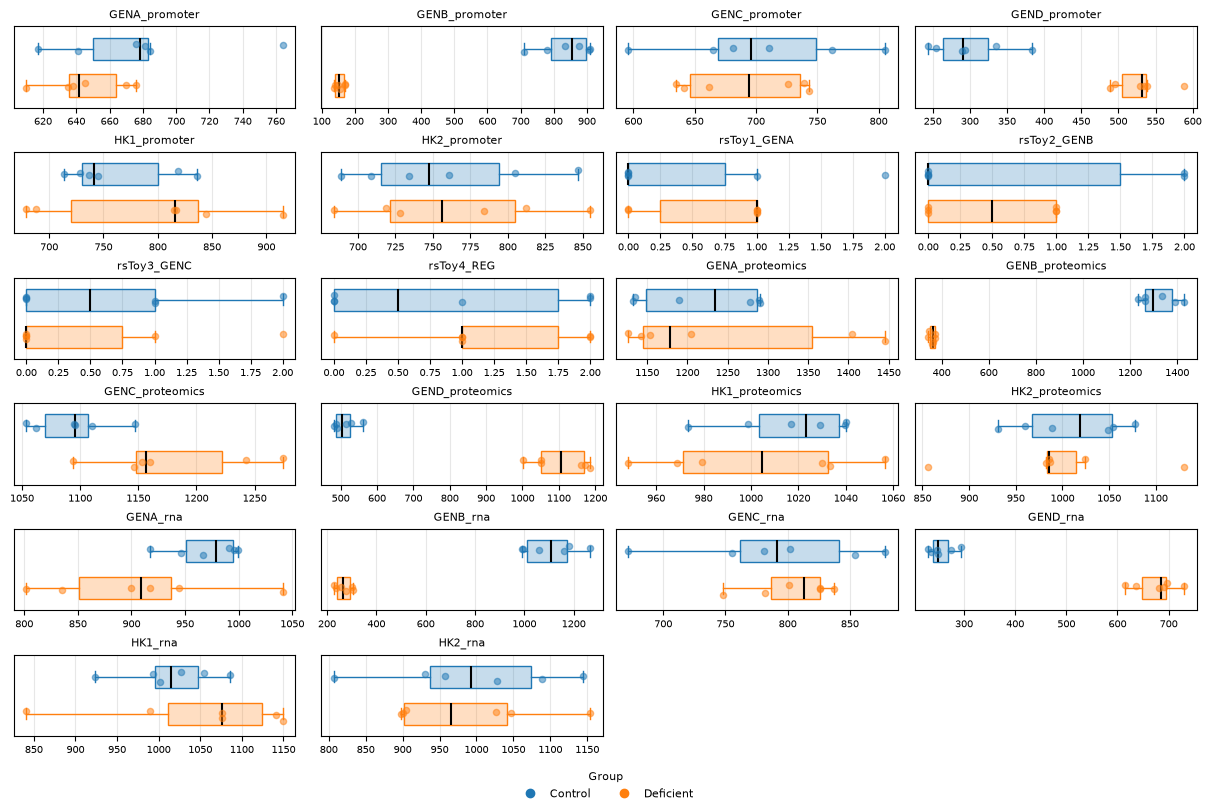

In [18]:
groups = sorted(df['group'].dropna().unique())
palette = dict(zip(groups, plt.cm.tab10(np.arange(len(groups)))))

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(42)

for ax, col in zip(axes, features):
    sub = df[[col, 'group']].dropna(subset=[col])

    for pos, g in enumerate(groups, start=1):
        data = sub.loc[sub['group'] == g, col].values
        if len(data) == 0:
            continue

        ax.boxplot(
            data, positions=[pos], orientation='horizontal',
            widths=0.6, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor=to_rgba(palette[g], 0.25), edgecolor=palette[g]),
            whiskerprops=dict(color=palette[g]),
            capprops=dict(color=palette[g]),
            medianprops=dict(color='black', linewidth=1.5)
        )

        y = rng.normal(pos, 0.07, size=len(data))
        ax.scatter(data, y, s=20, alpha=0.5, color=palette[g], zorder=3)

    ax.set_title(col, fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(len(groups) + 0.6, 0.4)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

for ax in axes[len(features):]:
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', linestyle='', color=palette[g], markersize=6, label=str(g)) for g in groups]

fig.legend(
    handles=handles, title='Group', loc='outside lower center',
    ncol=len(groups), fontsize=8, title_fontsize=8, frameon=False
)

fig;

O mesmo gráfico pode separar as amostras pelo lote de processamento em vez do grupo. Se uma variável mudasse de um lote para o outro, a diferença poderia ter origem técnica, na forma como as amostras foram processadas.

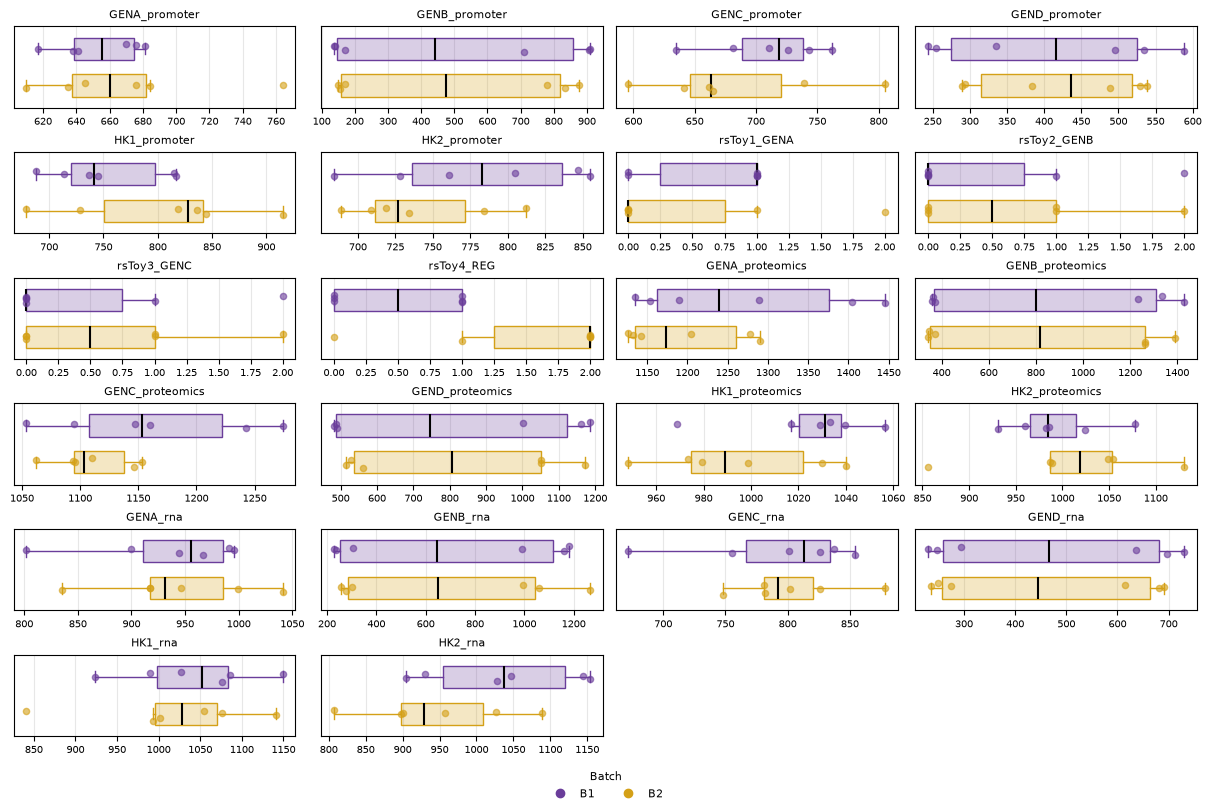

In [19]:
batches = sorted(df['batch'].dropna().unique())
palette = dict(zip(batches, ['#6a3d9a', '#d4a017']))

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(42)

for ax, col in zip(axes, features):
    sub = df[[col, 'batch']].dropna(subset=[col])

    for pos, b in enumerate(batches, start=1):
        data = sub.loc[sub['batch'] == b, col].values
        if len(data) == 0:
            continue

        ax.boxplot(
            data, positions=[pos], orientation='horizontal',
            widths=0.6, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor=to_rgba(palette[b], 0.25), edgecolor=palette[b]),
            whiskerprops=dict(color=palette[b]),
            capprops=dict(color=palette[b]),
            medianprops=dict(color='black', linewidth=1.5)
        )

        y = rng.normal(pos, 0.07, size=len(data))
        ax.scatter(data, y, s=20, alpha=0.6, color=palette[b], zorder=3)

    ax.set_title(col, fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(len(batches) + 0.6, 0.4)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

for ax in axes[len(features):]:
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', linestyle='', color=palette[b], markersize=6, label=str(b)) for b in batches]

fig.legend(
    handles=handles, title='Batch', loc='outside lower center',
    ncol=len(batches), fontsize=8, title_fontsize=8, frameon=False
)

fig;

# 4. Pré-processamento <a id="pre-processamento"></a>

## 4.1. Valores ausentes

Um valor ausente é uma medição que não existe para uma amostra, e a célula correspondente da tabela fica vazia (`NaN`). Em dados reais isso é comum, por exemplo quando uma proteína fica abaixo do limite de detecção do equipamento.

A maioria dos algoritmos de aprendizado de máquina não funciona com valores ausentes. As saídas mais comuns são:

- remover as amostras com valores ausentes;
- remover a variável inteira;
- preencher o valor que falta, por exemplo com a mediana da variável, o que se chama imputação.

A célula abaixo conta os valores ausentes de cada coluna da tabela.

In [20]:
df.isnull().sum()

sample_id          0
GENA_promoter      0
GENB_promoter      0
GENC_promoter      0
GEND_promoter      0
HK1_promoter       0
HK2_promoter       0
rsToy1_GENA        0
rsToy2_GENB        0
rsToy3_GENC        0
rsToy4_REG         0
group              0
phenotype          0
batch              0
GENA_proteomics    0
GENB_proteomics    0
GENC_proteomics    0
GEND_proteomics    0
HK1_proteomics     0
HK2_proteomics     0
GENA_rna           0
GENB_rna           0
GENC_rna           0
GEND_rna           0
HK1_rna            0
HK2_rna            0
dtype: int64

## 4.2. Efeito do lote

Amostras costumam ser processadas em levas, chamadas de lotes (*batches*), que podem diferir no dia, no reagente, no operador ou no equipamento. Cada lote pode deslocar as medições por motivos técnicos, e esse deslocamento é o efeito do lote.

O problema fica grave quando o lote se mistura com o grupo biológico. À esquerda, na figura abaixo, um biomarcador parece separar doentes de saudáveis. À direita, as mesmas amostras aparecem coloridas pelo lote, e todos os doentes estão num lote e todos os saudáveis no outro. Com esses dados, não há como saber se a diferença vem da doença ou do lote, porque as duas variáveis estão confundidas.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/confounding.png" alt="" width="600">
</div>

A tabela abaixo cruza lote e grupo. Quando cada lote tem controles e `Deficient` em proporções parecidas, um deslocamento técnico atinge os dois grupos da mesma forma e não se confunde com o fenótipo. Os boxplots por lote da seção 3.4 mostram se alguma variável muda de um lote para o outro, e o simulador da seção 9 permite criar o caso confundido.

In [ ]:
df_cross = pd.crosstab(df["batch"], df["group"], margins=True, margins_name="Total")
df_cross

group,Control,Deficient,Total
batch,,,
B1,3,3,6
B2,3,3,6
Total,6,6,12


## 4.3. Normalização das contagens

Nas camadas de ATAC e RNA, cada valor é uma contagem de leituras, e o total de leituras varia de uma amostra para outra por razões técnicas, como a quantidade de material sequenciado. Uma amostra sequenciada com o dobro de profundidade tem, em média, o dobro de leituras em todos os genes, sem nenhuma diferença biológica. Normalizar é estimar esse fator técnico de cada amostra e dividir as contagens por ele.

A estimativa mais simples do fator é o total de leituras da amostra, e ela falha quando poucos genes mudam muito. Na figura abaixo, cada ponto é um gene medido em duas amostras, e o gene C cai na amostra 2. Com a divisão pelo total (linha azul), os outros quatro genes parecem subir. Com um fator que desconsidera o gene C (linha vermelha), só ele muda. Essa distorção se chama efeito de composição.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/countdata-normalization.png" alt="" width="400">
</div>

O formulário abaixo aplica um de quatro métodos às camadas de ATAC e RNA:

- `NENHUMA`: mantém as contagens brutas;
- `CPM` (contagens por milhão): divide cada contagem pelo total de leituras da amostra e multiplica por um milhão;
- `HK`: divide pela média dos dois genes housekeeping, que não devem mudar entre os grupos;
- `MR` (mediana das razões): compara cada gene com a média geométrica dele entre as amostras e usa a mediana dessas razões como fator, como faz o DESeq2.

A proteômica fica de fora, porque não é contagem de leituras. A tabela normalizada, `df_norm`, segue para o resto da análise, então a escolha feita aqui afeta todas as seções seguintes. Como GENB perde muitas leituras no grupo `Deficient`, este dataset tem as condições para o efeito de composição, e a seção 4.4 permite ver o que cada método faz com os outros genes.

In [22]:
def normalize(df_counts, method):
    # nenhuma normalização
    if method == "NENHUMA":
        return df_counts.copy()
    # contagens por milhão
    if method == "CPM":
        total = df_counts.sum(axis=1)
        return df_counts.div(total, axis=0) * 1e6
    # divisão pela média das contagens de housekeeping
    if method == "HK":
        hk_cols = [c for c in df_counts.columns if c.startswith("HK")]
        factor = df_counts[hk_cols].mean(axis=1)
        # fator relativo à média das amostras, para manter a escala de contagem
        factor = factor / factor.mean()
        return df_counts.div(factor, axis=0)
    # mediana das razões
    if method == "MR":
        reference = np.exp(np.log(df_counts).mean(axis=0))
        ratios = df_counts.div(reference, axis=1)
        factor = ratios.median(axis=1)
        return df_counts.div(factor, axis=0)
    raise ValueError(f"Método de normalização desconhecido: {method}")

In [23]:
atac_cols = [c for c in df.columns if c.endswith("_promoter")]
rna_cols = [c for c in df.columns if c.endswith("_rna")]

In [24]:
metodo = "CPM"  #@param ["NENHUMA", "CPM", "HK", "MR"] {type:"string"}

df_norm = df.copy()
df_norm[atac_cols] = normalize(df[atac_cols], metodo)
df_norm[rna_cols] = normalize(df[rna_cols], metodo)
df_norm

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,152157.829840,224414.303329,167940.813810,62885.326757,183723.797781,208877.928483,0,0,2,...,1053.74,481.60,1029.16,931.07,188850.967008,223549.488055,143155.100493,43610.163064,205915.813424,194918.467956
1,S02,176196.636481,183699.870634,183958.602846,63130.659767,184734.799483,208279.430789,1,0,0,...,1095.08,489.61,1039.74,960.05,190279.417552,228256.591893,168044.077135,48799.685163,181621.408894,182998.819362
2,S03,154756.156446,218734.910671,183969.097055,80878.802511,177933.365524,183727.667793,0,2,1,...,1146.85,487.02,1017.06,1077.44,193592.498535,193397.147880,131275.639773,57628.443055,200625.122094,223481.148662
3,S04,171000.000000,208250.000000,166250.000000,73250.000000,209000.000000,172250.000000,0,0,0,...,1095.92,561.81,973.28,989.07,169689.119171,234455.958549,148408.586232,50888.230940,195040.710585,201517.394523
4,S05,165808.192298,191071.866569,197449.104734,70885.454991,200883.002208,173902.379200,0,2,0,...,1061.68,529.04,998.58,1054.18,198406.040268,208892.617450,163800.335570,49496.644295,210151.006711,169253.355705
5,S06,187209.017398,214408.233276,146042.636609,94094.584661,178387.650086,179857.877971,2,0,1,...,1110.27,515.51,1040.04,1048.68,194509.345794,206191.588785,170950.155763,48676.012461,193341.121495,186331.775701
6,S07,173087.357569,37167.661422,201573.521432,134563.212154,221649.484536,231958.762887,1,0,0,...,1159.84,1186.16,1056.43,982.24,186721.991701,63070.539419,173651.452282,131950.207469,205186.721992,239419.087137
7,S08,189909.297052,48469.387755,205782.312925,166950.113379,195011.337868,193877.551020,1,1,0,...,1242.83,1001.16,968.70,985.71,201494.130203,48665.955176,170971.184632,156029.882604,229669.156884,193169.690502
8,S09,191609.977324,39399.092971,179988.662132,151643.990930,231009.070295,206349.206349,1,0,0,...,1274.07,1162.20,1033.40,1023.61,168629.100084,49621.530698,173675.357443,146341.463415,241589.571068,220142.977292
9,S10,170094.936709,45094.936709,194883.966245,141877.637131,241297.468354,206751.054852,0,1,1,...,1094.24,1051.27,1029.77,1130.74,229093.309859,56117.957746,181778.169014,149867.957746,185079.225352,198063.380282


## 4.4. Tamanho de efeito

O **tamanho de efeito** mede o quanto dois grupos diferem numa variável. A forma mais direta de medi-lo é a distância entre os centros dos grupos, como a seta vermelha da figura abaixo.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/effectsize.png" alt="" width="300">
</div>

Em dados de contagem, a mesma diferença absoluta tem pesos diferentes para um gene com poucas leituras e para um gene com muitas. Por isso, em ômica, a comparação costuma usar a razão entre as médias, o fold change: um gene que dobra no grupo `Deficient` tem fold change 2, e um gene que cai pela metade tem fold change 0,5.

A célula abaixo mostra a média de acessibilidade de cada promotor nos dois grupos, já normalizada.

In [25]:
df_norm[["group", "GENA_promoter", "GENB_promoter", "GENC_promoter", "GEND_promoter"]].groupby("group").mean()

,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter
group,,,,
Control,677.166667,835.5,703.333333,300.000000
Deficient,645.666667,153.5,691.000000,529.333333


Na escala log2, a razão vira uma diferença, e dobrar ou cair pela metade ficam à mesma distância do zero ($+1$ e $-1$). O log2 fold change de uma variável é $\log_2 FC = \bar{b} - \bar{a}$, em que $\bar{a}$ e $\bar{b}$ são as médias de $\log_2(x + 1)$ nos controles e no grupo `Deficient`. O $+1$ evita o logaritmo de zero, e a seção 5 volta a essa transformação.

O log2 fold change não diz se a diferença é grande em relação à variação dentro de cada grupo. O d de Cohen mede isso, dividindo a diferença pelo desvio padrão combinado $s$ dos dois grupos:

$$d = \frac{\bar{b} - \bar{a}}{s}, \qquad s = \sqrt{\frac{s_a^2 + s_b^2}{2}},$$

em que $s_a^2$ e $s_b^2$ são as variâncias de cada grupo. Um $d$ igual a 1 indica centros a um desvio padrão de distância. Quanto maior o $d$, menos os grupos se sobrepõem, e é essa sobreposição que decide se uma variável, sozinha, consegue separar as amostras de um grupo das do outro. A célula abaixo calcula as duas medidas para cada variável.

In [ ]:
variables = [c for c in df_norm.columns if c.endswith(("_promoter", "_rna", "_proteomics"))]
control = df_norm[df_norm["phenotype"] == 0]
deficient = df_norm[df_norm["phenotype"] == 1]

rows = []
for col in variables:
    a = np.log2(control[col] + 1)
    b = np.log2(deficient[col] + 1)
    log2fc = b.mean() - a.mean()
    deviation = np.sqrt((a.var() + b.var()) / 2)
    d = log2fc / deviation
    rows.append({"variable": col, "log2fc": log2fc, "d": d})

df_dif = pd.DataFrame(rows)
df_dif

## 4.5. Teste de hipótese e p-valor

Uma diferença entre as médias de dois grupos pode aparecer só por acaso, porque cada grupo reúne poucas pessoas. O teste de hipótese avalia se os dados trazem evidência de uma diferença real, em quatro passos:

1. definir a hipótese nula $H_0$, de que não há diferença entre os grupos, e a hipótese alternativa $H_a$, de que há;
2. calcular uma estatística de teste, um número que resume a evidência contra $H_0$;
3. calcular o p-valor dessa estatística;
4. rejeitar $H_0$ se o p-valor for menor que um limite $\alpha$ escolhido antes, em geral 0,05.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/density.png" alt="" width="900">
</div>

O **p-valor** é a probabilidade de observar uma estatística de teste tão extrema quanto a observada, ou mais, supondo que $H_0$ seja verdadeira. Na figura acima, a curva mostra os valores que a estatística assume quando não há diferença, e o p-valor é a área além do valor observado, somadas as duas caudas. Um p-valor pequeno indica que o resultado seria raro se não houvesse diferença. Ele não é a probabilidade de $H_0$ ser verdadeira.

Rejeitar $H_0$ quando ela é verdadeira é um falso positivo, também chamado de erro do tipo I, e $\alpha$ é a probabilidade de cometê-lo em cada teste.

Para comparar as médias de dois grupos, usa-se o teste t. Com grupos do mesmo tamanho, como aqui, a estatística do teste é

$$t = c \cdot \frac{\bar{b} - \bar{a}}{s} = c \cdot d, \qquad c = \sqrt{\frac{n_a n_b}{n_a + n_b}},$$

em que $n_a$ e $n_b$ são os números de amostras de cada grupo. A estatística t é o d de Cohen multiplicado por um fator que cresce com o tamanho da amostra. Com muitas amostras, um efeito pequeno pode dar um p-valor pequeno; com poucas, só um efeito grande consegue.

A célula abaixo aplica o teste t a cada variável, na escala log2, e acrescenta o p-valor à tabela.

In [ ]:
p_values = []
for col in variables:
    a = np.log2(control[col] + 1)
    b = np.log2(deficient[col] + 1)
    p_values.append(stats.ttest_ind(b, a).pvalue)

df_dif["p"] = p_values
df_dif

## 4.6. Testes múltiplos

A tabela tem um teste por variável. Com $\alpha = 0{,}05$, cada teste tem 5% de chance de dar um falso positivo, e a chance de haver pelo menos um falso positivo entre todos os testes cresce com o número de testes $m$. Essa chance é a taxa de erro por família (FWER, *family-wise error rate*). Se os testes forem independentes e nenhuma diferença for real, $\text{FWER} = 1 - (1 - \alpha)^m$.

A figura abaixo mostra a FWER em função do número de testes. Em ômica, com milhares de genes testados de uma vez, alguns p-valores pequenos aparecem só por acaso.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/fwer.png" alt="" width="600">
</div>

O formulário abaixo permite escolher entre duas correções:

- Bonferroni controla a FWER: só rejeita $H_0$ quando o p-valor é menor que $\alpha / m$. É uma correção rigorosa, que, com muitos testes, deixa passar poucos resultados.
- Benjamini-Hochberg controla a taxa de falsas descobertas (FDR, *false discovery rate*), que é a proporção esperada de falsos positivos entre os resultados declarados significativos. Ela aceita alguns falsos positivos para perder menos efeitos reais, o que combina com análises exploratórias como as de ômica.

A célula transforma cada p-valor num p-valor corrigido (`p_corrected`), que pode ser comparado diretamente com 0,05.

In [27]:
correction = "BENJAMINI_HOCHBERG"  #@param ["NENHUMA", "BONFERRONI", "BENJAMINI_HOCHBERG"] {type:"string"}

# sem correção
if correction == "NENHUMA":
    df_dif["p_corrected"] = df_dif["p"]
# correção de Bonferroni
elif correction == "BONFERRONI":
    df_dif["p_corrected"] = (df_dif["p"] * len(df_dif)).clip(upper=1)
# correção de Benjamini-Hochberg
elif correction == "BENJAMINI_HOCHBERG":
    df_dif["p_corrected"] = stats.false_discovery_control(df_dif["p"], method="bh")
else:
    raise ValueError(f"Método de correção desconhecido: {correction}")

df_dif["significant"] = df_dif["p_corrected"] < 0.05
df_dif.sort_values("p_corrected")

,variable,log2fc,d,p,p_corrected,significant
7,GENB_proteomics,-1.872182,-26.056909,6.863041e-13,1.235347e-11,True
1,GENB_promoter,-2.269254,-17.542583,3.492312e-11,3.143081e-10,True
15,GEND_rna,1.533572,13.672714,4.090381e-10,2.454229e-09,True
13,GENB_rna,-1.927202,-13.200167,5.780646e-10,2.601291e-09,True
9,GEND_proteomics,1.111037,11.641969,1.980891e-09,7.131209e-09,True
3,GEND_promoter,1.009336,5.788120,1.553128e-06,4.659385e-06,True
4,HK1_promoter,0.224935,1.934285,7.361874e-03,1.893053e-02,True
8,GENC_proteomics,0.105970,1.616720,1.878680e-02,4.227029e-02,True
5,HK2_promoter,0.186440,1.544598,2.327892e-02,4.655784e-02,True
14,GENC_rna,0.158108,1.394436,3.635666e-02,6.204477e-02,False


O gráfico de vulcão (*volcano plot*) junta o tamanho de efeito e o teste num só gráfico. O eixo horizontal é o log2 fold change: à direita ficam as variáveis que sobem no grupo `Deficient`, e à esquerda as que caem. O eixo vertical é $-\log_{10}$ do p-valor corrigido, de modo que quanto mais alto o ponto, menor o p-valor.

A linha tracejada marca 0,05, e os pontos acima dela aparecem em vermelho, com o nome da variável. Vale refazer o gráfico trocando a normalização na seção 4.3 e a correção no formulário acima.

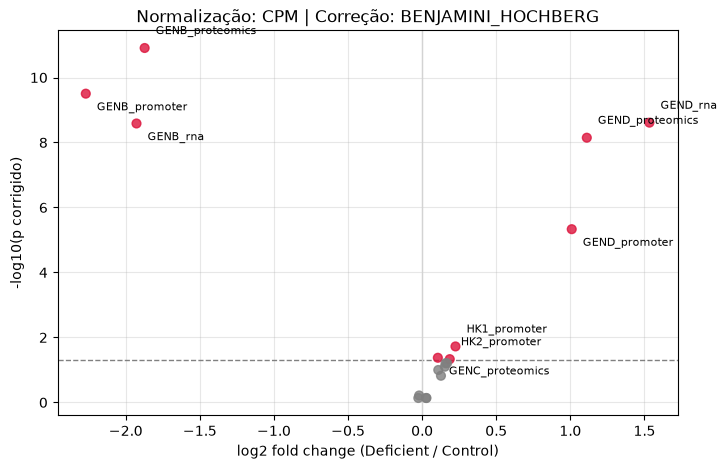

In [28]:
limit = 0.05
df_dif["minus_log10_p"] = -np.log10(df_dif["p_corrected"])
colors = df_dif["significant"].map({True: "crimson", False: "gray"})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_dif["log2fc"], df_dif["minus_log10_p"], c=colors, s=40, alpha=0.8, zorder=3)
ax.axhline(-np.log10(limit), color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)

significant = df_dif[df_dif["significant"]].sort_values("minus_log10_p")
for i, (_, linha) in enumerate(significant.iterrows()):
    shift = 10 if i % 2 == 0 else -12
    ax.annotate(
        linha["variable"],
        (linha["log2fc"], linha["minus_log10_p"]),
        xytext=(8, shift), textcoords="offset points", fontsize=8,
    )
    
ax.set_title(f"Normalização: {metodo} | Correção: {correction}")
ax.set_xlabel("log2 fold change (Deficient / Control)")
ax.set_ylabel("-log10(p corrigido)")
ax.grid(alpha=0.3)

# 5. Transformação <a id="transformacao"></a>

## 5.1. Transformação logarítmica

As funções abaixo montam a tabela $X$ e o vetor $y$ da seção 3.3 a partir de `df_norm`. A função `layer_columns` encontra as colunas de cada camada pelo sufixo, e `build_xy` junta as camadas pedidas, retira os genes indicados e transforma os valores. As seções 8 e 9 usam as mesmas funções para montar outras versões de $X$.

Nas variáveis contínuas, a transformação é $\log_2(x + 1)$, a mesma do log2 fold change da seção 4.4. Contagens e intensidades têm distribuição assimétrica, com poucos valores muito altos, e variam por multiplicação: quando um gene dobra de expressão, o aumento em números absolutos é maior se ele já estava alto. Na escala logarítmica, uma mesma mudança multiplicativa vira uma mesma distância, porque $\log(a \cdot x) = \log a + \log x$.

Os genótipos continuam como 0, 1 ou 2. Tratá-los como número supõe que cada cópia do alelo acrescenta o mesmo efeito, o que se chama modelo aditivo.

In [29]:
all_layers = ["ATAC", "RNA", "PROTEOMICA", "GENOTIPOS"]
genes = ["GENA", "GENB", "GENC", "GEND", "HK1", "HK2"]
group_colors = {"Control": "tab:blue", "Deficient": "tab:orange"}

In [30]:
def layer_columns(data, layer):
    if layer == "ATAC":
        return [c for c in data.columns if c.endswith("_promoter")]
    if layer == "RNA":
        return [c for c in data.columns if c.endswith("_rna")]
    if layer == "PROTEOMICA":
        return [c for c in data.columns if c.endswith("_proteomics")]
    if layer == "GENOTIPOS":
        return [c for c in data.columns if c.startswith("rs")]
    raise ValueError(f"Camada desconhecida: {layer}")

In [31]:
def build_xy(data, layers, excluded_genes=()):
    columns = []
    for layer in layers:
        columns += layer_columns(data, layer)
    columns = [c for c in columns if c.startswith("rs") or c.split("_")[0] not in excluded_genes]
    if len(columns) == 0:
        raise ValueError("Nenhuma variável selecionada")

    X = data[columns].copy()
    continuous = [c for c in columns if not c.startswith("rs")]
    X[continuous] = np.log2(X[continuous] + 1)
    y = data["phenotype"]
    return X, y

In [32]:
X, y = build_xy(df_norm, all_layers)

print(f"Amostras: {X.shape[0]}, variáveis: {X.shape[1]}")
X

Amostras: 12, variáveis: 22


,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,GENA_rna,GENB_rna,GENC_rna,GEND_rna,...,GENA_proteomics,GENB_proteomics,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,17.215219,17.775812,17.357602,15.940459,17.487187,17.672307,17.526896,17.770241,17.127230,15.412410,...,10.148896,10.483685,10.042672,8.914684,10.008653,9.864294,0,0,2,1
1,17.426835,17.486999,17.489029,15.946076,17.495104,17.668168,17.537768,17.800303,17.358489,15.574614,...,10.217206,10.268717,10.098137,8.938433,10.023394,9.908468,1,0,0,0
2,17.239647,17.738831,17.489112,16.303492,17.440986,17.487217,17.562671,17.561214,17.002251,15.814518,...,10.333536,10.382786,10.164718,8.930796,9.991607,10.074730,0,2,1,0
3,17.383645,17.667964,17.343003,16.160561,17.673150,17.394153,17.372543,17.838964,17.179225,15.635073,...,10.334530,10.304294,10.099243,9.136504,9.928193,9.951387,0,0,0,0
4,17.339164,17.543763,17.591129,16.113222,17.616003,17.407926,17.598104,17.672409,17.321588,15.595072,...,10.321105,10.302639,10.053492,9.049957,9.965178,10.043273,0,2,0,2
5,17.514298,17.710008,17.156040,16.521839,17.444664,17.456506,17.569487,17.653633,17.383225,15.570953,...,10.146301,10.444684,10.117994,9.012652,10.023810,10.035734,2,0,1,2
6,17.401149,15.181799,17.620954,17.037935,17.757927,17.823515,17.510540,15.944702,17.405843,17.009645,...,10.497862,8.514201,10.180953,10.213299,10.046346,9.941400,1,0,0,1
7,17.534959,15.564816,17.650766,17.349066,17.573206,17.564794,17.620385,15.570655,17.383402,17.251472,...,10.457094,8.497173,10.280574,9.968897,9.921395,9.946482,1,1,0,0
8,17.547821,15.265911,17.457555,17.210338,17.817596,17.654735,17.363503,15.598708,17.406042,17.158989,...,10.172765,8.546200,10.316361,10.183883,10.014578,10.000859,1,0,0,1
9,17.375989,15.460710,17.572263,17.114298,17.880459,17.657542,17.805582,15.776201,17.471827,17.193342,...,10.234817,8.549323,10.097031,10.039289,10.009507,10.144327,0,1,1,2


A figura abaixo mostra três variáveis de RNA, uma por linha, com as amostras coloridas pelo grupo: GENB e GEND, que diferem entre os grupos, e HK1, um housekeeping. À esquerda está o valor normalizado e, à direita, o mesmo valor depois do log. O log preserva a ordem das amostras e altera as distâncias entre elas, aproximando os valores altos e afastando os baixos.

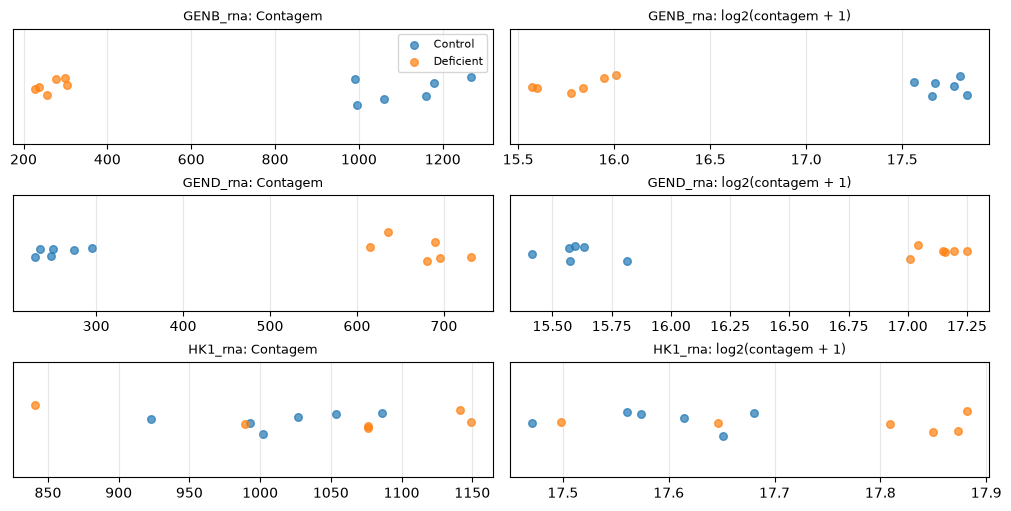

In [33]:
example_columns = ["GENB_rna", "GEND_rna", "HK1_rna"]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(nrows=len(example_columns), ncols=2, figsize=(10, 5), constrained_layout=True)

for row, col in enumerate(example_columns):
    for pos, (label, values) in enumerate([("escala linear", df_norm[col]), ("log2(x + 1)", X[col])]):
        ax = axes[row, pos]
        for g, color in group_colors.items():
            mask = df["group"] == g
            ax.scatter(values[mask], rng.normal(0, 0.05, mask.sum()), s=30, alpha=0.7, color=color, label=g)
        ax.set_yticks([])
        ax.set_ylim(-0.3, 0.3)
        ax.set_title(f"{col}: {label}", fontsize=9)
        ax.grid(axis="x", alpha=0.3)

axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Normalização: {metodo}", fontsize=10)
fig;

## 5.2. Padronização

Mesmo depois do log, as camadas continuam em escalas diferentes, e os genótipos variam só de 0 a 2. A maioria dos algoritmos de aprendizado de máquina funciona mal quando as variáveis têm escalas muito diferentes, porque as de valores maiores dominam os cálculos.

A **padronização** coloca todas as variáveis na mesma escala. De cada valor, subtrai-se a média da variável, e o resultado é dividido pelo desvio padrão:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j},$$

em que $\bar{x}_j$ e $s_j$ são a média e o desvio padrão da variável $j$. Depois disso, toda variável tem média 0 e desvio padrão 1, e $z_{ij}$ indica a quantos desvios padrão da média está a amostra $i$.

A figura abaixo compara as variáveis antes e depois da padronização. Aqui a padronização usa todas as amostras, apenas para visualização. Na seção 6, ela é refeita a cada rodada da validação cruzada, só com as amostras de treino.

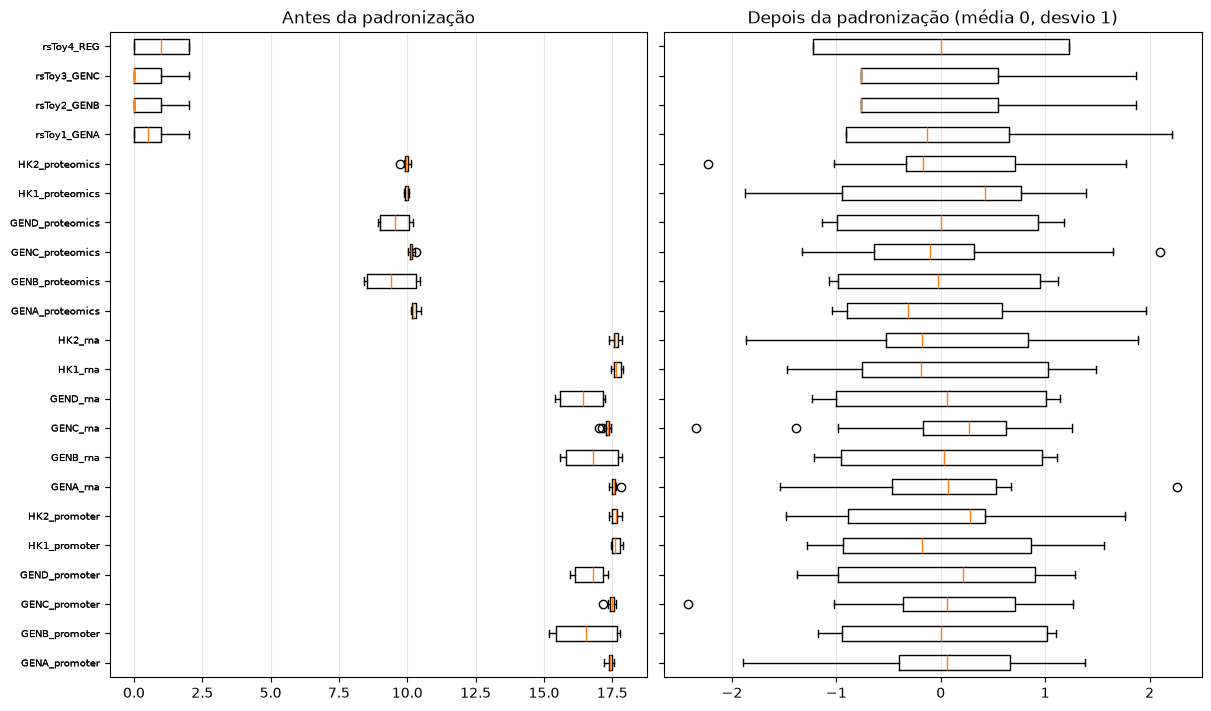

In [34]:
X_scaled_view = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

fig, axes = plt.subplots(ncols=2, figsize=(12, 7), sharey=True, constrained_layout=True)

axes[0].boxplot(X.values, orientation="horizontal", tick_labels=X.columns)
axes[0].set_title("Antes da padronização")
axes[1].boxplot(X_scaled_view.values, orientation="horizontal", tick_labels=X.columns)
axes[1].set_title("Depois da padronização (média 0, desvio 1)")

for ax in axes:
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

fig;

## 5.3. PCA e variância explicada

Com 22 variáveis, não é possível desenhar as amostras num único gráfico. A análise de componentes principais (PCA, *principal component analysis*) reduz o número de dimensões preservando o máximo possível da variação entre as amostras. Ela procura a direção ao longo da qual os dados mais variam, o primeiro componente principal (PC1). Depois, entre as direções perpendiculares à primeira, procura a que concentra mais variação restante, o PC2, e assim por diante.

Na figura abaixo, à esquerda, um conjunto de pontos em duas dimensões aparece com três eixos candidatos. À direita está a projeção dos pontos em cada eixo. A projeção na linha sólida é a que preserva mais variância, e essa linha é o PC1.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/pca.png" alt="" width="800">
</div>

A **variância explicada** de um componente é a fração da variação total dos dados que está ao longo dele, e aparece nos eixos do gráfico abaixo. Como o resultado do PCA depende da escala das variáveis, elas são padronizadas antes.

O PCA é um método não supervisionado: ele usa só a tabela $X$, sem o rótulo. As cores do gráfico são aplicadas depois. Por isso, se os grupos aparecem separados no PC1, a maior fonte de variação do dataset coincide com a diferença entre controles e `Deficient`. O formulário permite repetir o PCA com uma camada de cada vez.

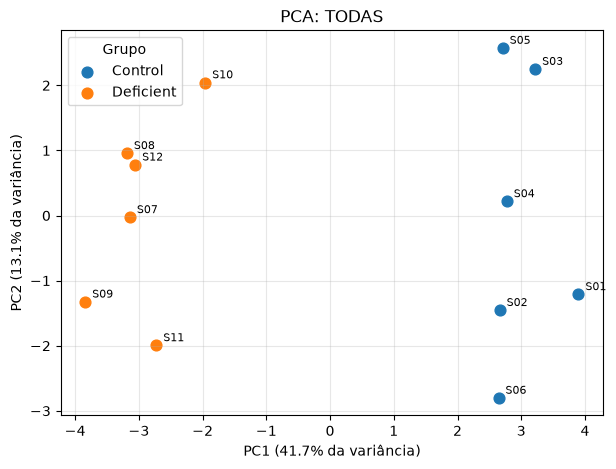

In [35]:
camada_pca = "TODAS"  #@param ["TODAS", "ATAC", "RNA", "PROTEOMICA", "GENOTIPOS"] {type:"string"}

layers_pca = all_layers if camada_pca == "TODAS" else [camada_pca]
X_pca, _ = build_xy(df_norm, layers_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(StandardScaler().fit_transform(X_pca))
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 5))
for g, color in group_colors.items():
    mask = (df["group"] == g).values
    ax.scatter(components[mask, 0], components[mask, 1], s=60, color=color, label=g)
for i, sample in enumerate(df["sample_id"]):
    ax.annotate(sample, (components[i, 0], components[i, 1]), xytext=(5, 3), textcoords="offset points", fontsize=8)

ax.set_title(f"PCA: {camada_pca}")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% da variância)")
ax.legend(title="Grupo")
ax.grid(alpha=0.3)

# 6. Mineração de dados <a id="mineracao"></a>

## 6.1. Aprendizado supervisionado

No **aprendizado supervisionado**, o modelo recebe exemplos já rotulados e aprende uma regra que leva das variáveis ao rótulo. Depois de treinado, ele usa essa regra para prever o rótulo de amostras novas, que não viu durante o treino. Quando o rótulo é uma categoria, como controle ou `Deficient`, a tarefa se chama classificação.

Na figura abaixo, o conjunto de treinamento é formado por e-mails já marcados como spam ou não, e o modelo precisa classificar um e-mail novo. Nesta aula, cada amostra é uma pessoa, as variáveis são as medições das camadas moleculares e o rótulo é `phenotype`.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/supervised.png" alt="" width="800">
</div>

Os modelos desta seção são de aprendizado de máquina clássico: regressão logística, SVM e Random Forest. As redes neurais profundas (*deep learning*) se destacam em imagens, texto e sequências, quando há um volume muito grande de exemplos. Com poucas amostras e dados em tabela, elas raramente superam modelos mais simples, que são mais fáceis de treinar e de interpretar.

Com 12 amostras, os modelos clássicos são a escolha adequada. Quando métodos diferentes têm desempenho parecido, vale ficar com o mais simples.

## 6.2. Regressão logística

A **regressão logística** estima a probabilidade de uma amostra pertencer à classe positiva, aqui o grupo `Deficient`. Ela calcula uma soma ponderada das variáveis e passa o resultado pela função logística, que transforma qualquer número num valor entre 0 e 1:

$$p = \sigma(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p), \qquad \sigma(t) = \frac{1}{1 + e^{-t}},$$

em que $x_1, \dots, x_p$ são as variáveis da amostra, $\beta_1, \dots, \beta_p$ são os coeficientes, que o treino ajusta, e $\beta_0$ é o intercepto. Se $p \geq 0{,}5$, o modelo prevê `Deficient`, e caso contrário, controle. A figura abaixo mostra a função logística.

A fronteira entre as classes é linear (uma reta, quando há duas variáveis). É o mesmo tipo de modelo que o `glm(..., family = binomial)` ajusta no R, com uma diferença: o scikit-learn aplica por padrão uma penalidade leve aos coeficientes, assunto da seção 7.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/logreg.png" alt="" width="800">
</div>

## 6.3. SVM com núcleo RBF

A máquina de vetores de suporte (SVM, *support vector machine*) procura a fronteira que separa as classes com a maior folga possível. Na figura abaixo, à esquerda, há três fronteiras possíveis, e uma delas nem separa as classes. À direita, a linha contínua é a fronteira da SVM, que fica o mais longe possível das amostras mais próximas de cada classe. Essas amostras, na borda da folga, são os vetores de suporte, e só elas determinam a fronteira.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/svm.png" alt="" width="800">
</div>

Com o núcleo RBF (*radial basis function*), a fronteira pode ser curva. O núcleo mede a semelhança entre duas amostras $x$ e $x'$:

$$K(x, x') = \exp\left(-\gamma \lVert x - x' \rVert^2\right),$$

em que $\lVert x - x' \rVert$ é a distância entre elas e $\gamma$ controla o quão rápido a semelhança cai com a distância. A semelhança vale 1 quando as amostras coincidem e se aproxima de 0 quando elas se afastam, e a SVM passa a separar as classes com base nessas semelhanças. Como tudo depende de distâncias, a SVM é sensível à escala das variáveis, e a padronização da seção 5.2 é necessária antes dela.

## 6.4. Random Forest

Uma árvore de decisão classifica uma amostra por uma sequência de perguntas sobre as variáveis, como "a proteína de GENB está abaixo de tal valor?". Cada resposta leva a um ramo, até chegar a uma folha que dá a classe. Árvores são fáceis de ler, mas instáveis: pequenas mudanças nos dados de treino podem produzir árvores bem diferentes.

Uma Random Forest (floresta aleatória) treina muitas árvores e prevê a classe mais votada entre elas. Dois sorteios tornam as árvores diferentes entre si:

- cada árvore é treinada numa amostragem com reposição das amostras de treino (*bootstrap*), como na figura abaixo;
- a cada pergunta, a árvore escolhe a melhor variável dentro de um subconjunto sorteado das variáveis.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/bootstrap.png" alt="" width="800">
</div>

Esses sorteios dependem de uma semente (`random_state`), um número que fixa a sequência aleatória. Com a mesma semente, o resultado se repete. Com outra semente, a floresta muda, e a seção 7 mostra o efeito disso sobre a importância das variáveis.

A função `make_model` abaixo cria qualquer um dos três modelos pelo nome, e as seções seguintes a usam sempre que precisam de um modelo novo.

In [36]:
model_names = ["REGRESSAO_LOGISTICA", "SVM", "RANDOM_FOREST"]

def make_model(model_name, seed=42):
    if model_name == "REGRESSAO_LOGISTICA":
        return LogisticRegression(max_iter=1000)
    if model_name == "SVM":
        return SVC(kernel="rbf")
    if model_name == "RANDOM_FOREST":
        return RandomForestClassifier(n_estimators=100, random_state=seed)
    raise ValueError(f"Modelo desconhecido: {model_name}")

## 6.5. Treino e teste

Um modelo só é útil se acerta em amostras que não viu. Por isso, os dados são divididos em dois conjuntos: o de treino, usado para ajustar o modelo, e o de teste, usado apenas para medir o desempenho. O erro nas amostras de teste estima o erro de generalização, isto é, o erro esperado em amostras novas.

Medir o acerto nas mesmas amostras usadas no treino dá uma estimativa otimista, porque o modelo pode ter se ajustado a detalhes que só existem nelas.

## 6.6. Sobreajuste

O **sobreajuste** (*overfitting*) acontece quando o modelo se ajusta tanto aos dados de treino que passa a reproduzir o ruído deles, e então acerta muito no treino e pouco em amostras novas. O risco cresce com a complexidade do modelo e diminui com a quantidade de dados.

Com mais variáveis do que amostras, como aqui, o risco é alto. Na figura abaixo, à esquerda, uma reta ajustada a 20 pontos passa entre eles. À direita, com apenas 2 pontos, a reta passa exatamente pelos dois, quaisquer que sejam os valores. Nessa situação, um ajuste perfeito ao treino não diz nada sobre o desempenho em amostras novas.

Para reduzir o sobreajuste, é possível simplificar o modelo, reunir mais dados ou restringir o modelo durante o treino. Essa restrição se chama regularização e volta na seção 7.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/overfitting.png" alt="" width="800">
</div>

## 6.7. Validação cruzada

Com 12 amostras, separar um conjunto de teste deixaria poucas amostras para treinar e poucas para testar. A validação cruzada contorna isso repetindo a divisão várias vezes, de modo que cada amostra seja usada no teste uma vez.

Na validação cruzada deixando um de fora (LOOCV, *leave-one-out cross-validation*), cada rodada separa uma única amostra para teste e treina o modelo com todas as outras. Com $n$ amostras, são $n$ rodadas, e cada amostra recebe uma previsão feita por um modelo que nunca a viu. A figura abaixo mostra o esquema, com o treino em azul e a amostra de teste em bege.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/loocv.png" alt="" width="800">
</div>

Tudo o que é ajustado aos dados faz parte do treino, inclusive o pré-processamento. A padronização usa a média e o desvio padrão de cada variável. Se esses valores forem calculados com todas as amostras, a amostra de teste influencia o treino, e a avaliação fica otimista. Por isso, a função `evaluate` abaixo ajusta a padronização só nas amostras de treino de cada rodada e depois aplica os mesmos valores à amostra de teste.

O mesmo cuidado vale para a escolha de variáveis. Selecionar os genes de menor p-valor com todas as amostras e só depois validar o modelo é um erro comum em ômica, que produz acertos altos mesmo quando não há sinal.

In [37]:
def evaluate(X, y, model_name, seed=42):
    loo = LeaveOneOut()
    y_pred = np.zeros_like(y)

    for train_index, test_index in loo.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train = y.iloc[train_index]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = make_model(model_name, seed)
        model.fit(X_train_scaled, y_train)
        y_pred[test_index] = model.predict(X_test_scaled)

    return accuracy_score(y, y_pred), confusion_matrix(y, y_pred)

## 6.8. Métricas e linha de base

A **acurácia** é a fração de amostras classificadas corretamente. Sozinha, ela pode enganar, e por isso é comparada com uma linha de base: o acerto de uma regra trivial, como chutar sempre o grupo mais comum. Se 90% das amostras fossem de um grupo, chutar sempre esse grupo acertaria 90% sem aprender nada. A célula abaixo calcula a linha de base deste dataset.

In [38]:
baseline = y.value_counts(normalize=True).max()
print(f"Acerto de quem chuta sempre o mesmo grupo: {baseline:.0%}")

Acerto de quem chuta sempre o mesmo grupo: 50%


A matriz de confusão detalha acertos e erros: cada linha é o grupo real, e cada coluna é o grupo previsto. A diagonal conta os acertos, e as outras duas células contam os erros, que são prever `Deficient` para um controle ou prever controle para uma amostra `Deficient`. Na figura abaixo, de um classificador de dígitos, as quatro células aparecem nomeadas: verdadeiro negativo (TN), falso positivo (FP), falso negativo (FN) e verdadeiro positivo (TP).

O formulário abaixo escolhe o modelo, roda a LOOCV e mostra a acurácia e a matriz de confusão.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/confusion-matrix.png" alt="" width="800">
</div>

Acurácia: 100%


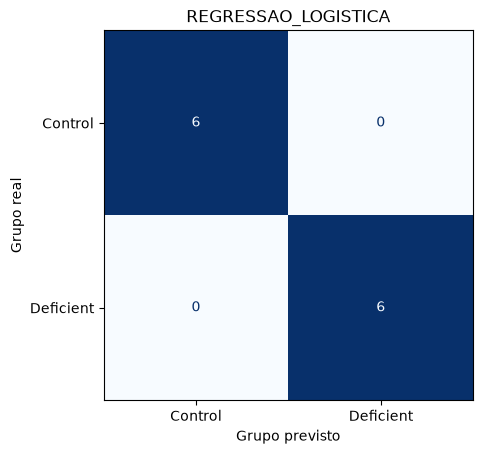

In [39]:
modelo = "REGRESSAO_LOGISTICA"  #@param ["REGRESSAO_LOGISTICA", "SVM", "RANDOM_FOREST"] {type:"string"}

accuracy, matrix = evaluate(X, y, modelo)
print(f"Acurácia: {accuracy:.0%}")

cm_display = ConfusionMatrixDisplay(matrix, display_labels=["Control", "Deficient"])
cm_display.plot(cmap="Blues", colorbar=False)
cm_display.ax_.set_title(modelo)
cm_display.ax_.set_xlabel("Grupo previsto")
cm_display.ax_.set_ylabel("Grupo real");

A célula abaixo repete a avaliação para os três modelos.

Com LOOCV, um detalhe importa quando as variáveis não trazem sinal. Ao tirar uma amostra de um grupo para teste, o treino fica com uma amostra a mais do outro grupo, e um modelo sem informação útil tende a prever a classe mais frequente no treino, que é justamente a errada. Por isso, sem sinal, a acurácia da LOOCV pode ficar bem abaixo da linha de base, em vez de oscilar em torno dela. As seções 8 e 9 mostram casos assim.

In [40]:
results = []
for model_name in model_names:
    accuracy, _ = evaluate(X, y, model_name)
    results.append({"model": model_name, "accuracy": accuracy})

pd.DataFrame(results)

,model,accuracy
0,REGRESSAO_LOGISTICA,1.0
1,SVM,1.0
2,RANDOM_FOREST,1.0


# 7. Interpretação e avaliação <a id="avaliacao"></a>

## 7.1. Coeficientes da regressão logística

Um modelo que acerta não diz, por si só, em que se apoiou. Na regressão logística, a resposta está nos coeficientes: cada um indica o quanto a variável empurra a previsão para `Deficient`, se for positivo, ou para controle, se for negativo. Como as variáveis estão padronizadas, os tamanhos dos coeficientes podem ser comparados entre si.

A célula abaixo ajusta a regressão logística com todas as amostras, porque o objetivo aqui é interpretar o modelo, e o acerto já foi medido na seção 6. Vale comparar os maiores coeficientes com os genes que se destacaram na seção 4.4 e observar se as variáveis de um mesmo gene dividem o peso entre si.

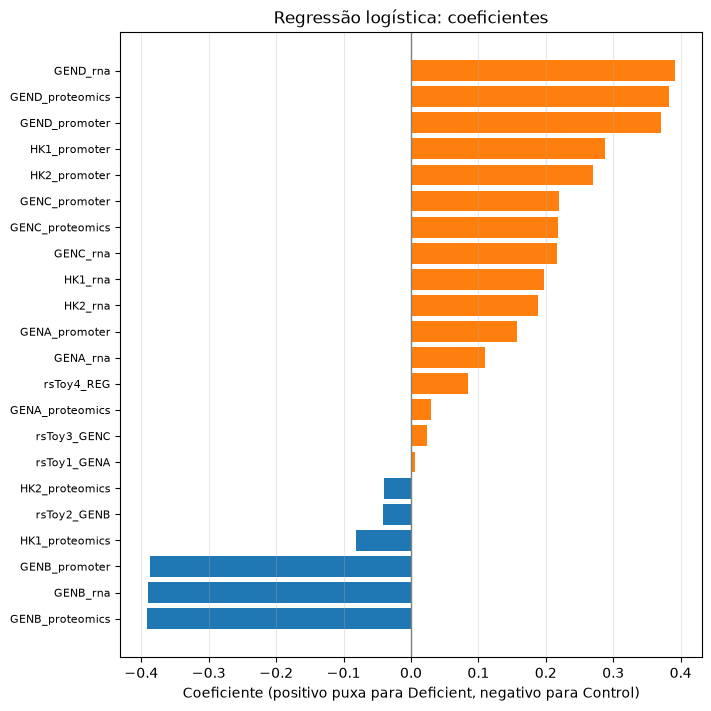

In [41]:
X_scaled_full = StandardScaler().fit_transform(X)
logreg = LogisticRegression(max_iter=1000).fit(X_scaled_full, y)
coefficients = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.barh(coefficients.index, coefficients.values, color=np.where(coefficients > 0, "tab:orange", "tab:blue"))
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Regressão logística: coeficientes")
ax.set_xlabel("Coeficiente (positivo puxa para Deficient, negativo para Control)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)

## 7.2. Importância de variáveis no Random Forest

No Random Forest, a **importância** de uma variável mede o quanto as perguntas feitas sobre ela reduzem a mistura de classes nos nós das árvores (a impureza), em média, em toda a floresta. As importâncias somam 1, e cada uma pode ser lida como a fração do trabalho de separação atribuída àquela variável. Na figura abaixo, uma floresta classifica imagens de dígitos, e cada pixel aparece colorido pela sua importância.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/importancia.png" alt="" width="800">
</div>

Como a floresta depende de sorteios, a célula abaixo treina uma floresta para cada uma de dez sementes e conta quantas vezes cada variável ficou em primeiro lugar. Se a primeira colocada mudar de uma semente para outra, a liderança depende do sorteio e não pode ser lida como uma propriedade dos dados.

In [42]:
def rf_importances(X, y, seeds):
    table = {}
    for seed in seeds:
        model = make_model("RANDOM_FOREST", seed)
        model.fit(X, y)
        table[seed] = model.feature_importances_
    return pd.DataFrame(table, index=X.columns)

In [43]:
importances = rf_importances(X, y, seeds=range(10))

importances.idxmax().value_counts()

GEND_promoter      5
GENB_promoter      3
GEND_proteomics    1
GENB_proteomics    1
Name: count, dtype: int64

O gráfico abaixo mostra a importância média das dez variáveis mais importantes, com a variação entre as sementes como barra de erro.

Quando várias variáveis carregam a mesma diferença entre os grupos, como as camadas de um gene que muda, qualquer uma delas serve ao modelo, e a escolha entre elas fica por conta do sorteio. Com muitas variáveis correlacionadas, não há como saber qual delas é a preditiva, e o modelo obtido é um entre muitos que funcionariam igualmente bem. Por isso, a importância aponta variáveis associadas ao rótulo, que não são necessariamente as que causam o fenótipo.

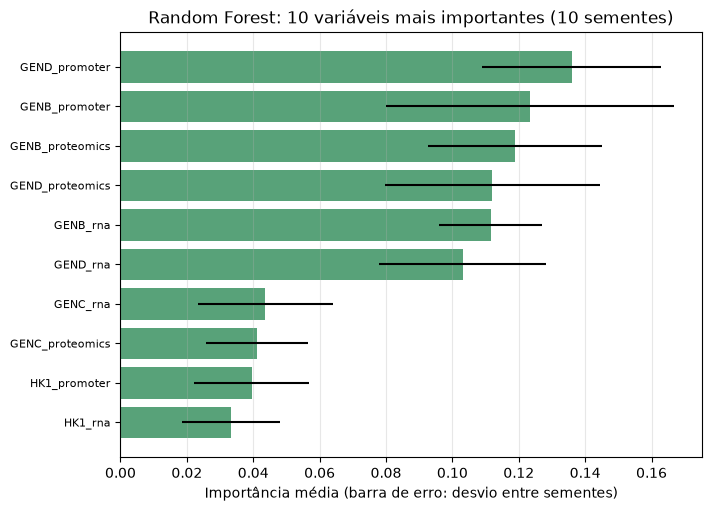

In [44]:
top_mean = importances.mean(axis=1).sort_values().tail(10)
top_std = importances.std(axis=1)[top_mean.index]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.barh(top_mean.index, top_mean.values, xerr=top_std.values, color="seagreen", alpha=0.8)
ax.set_title("Random Forest: 10 variáveis mais importantes (10 sementes)")
ax.set_xlabel("Importância média (barra de erro: desvio entre sementes)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)

## 7.3. Regularização L1 (lasso)

A regularização restringe o modelo durante o treino para reduzir o sobreajuste (seção 6.6). A regressão logística da seção 6 já usava uma forma dela, a penalidade L2, que soma os quadrados dos coeficientes e os encolhe sem zerá-los. O **lasso** usa a penalidade L1, a soma dos valores absolutos dos coeficientes:

$$\text{perda} + \lambda \sum_{j=1}^{p} |\beta_j|,$$

em que a perda mede o quanto as probabilidades previstas erram os rótulos do treino, $\beta_j$ são os coeficientes e $\lambda \geq 0$ controla a força da penalidade. Com $\lambda = 0$, o modelo é a regressão logística sem penalidade. Quanto maior o $\lambda$, mais caro fica ter coeficientes grandes, e o lasso passa a zerar os coeficientes das variáveis menos úteis. Na prática, ele seleciona variáveis, e o modelo resultante é esparso, com poucos coeficientes diferentes de zero.

No scikit-learn, a força da penalidade é dada por $C = 1/\lambda$: quanto maior o $C$, mais fraca a penalidade. No pacote `glmnet` do R, o parâmetro é o próprio $\lambda$, e o sentido é o oposto.

A função `make_lasso` abaixo cria a regressão logística com penalidade L1 para um valor de $C$. O teste de versão só acomoda uma mudança no nome do parâmetro entre versões do scikit-learn.

In [45]:
sklearn_version = tuple(int(v) for v in sklearn.__version__.split(".")[:2])

def make_lasso(C):
    if sklearn_version >= (1, 8):
        return LogisticRegression(l1_ratio=1, C=C, solver="liblinear", tol=1e-6, max_iter=10000)
    return LogisticRegression(penalty="l1", C=C, solver="liblinear", tol=1e-6, max_iter=10000)

## 7.4. Caminho do lasso

O **caminho do lasso** é o conjunto de coeficientes obtidos ao treinar o lasso com uma sequência de valores de $C$, da penalidade mais forte para a mais fraca. Com a penalidade forte, todos os coeficientes são zero. À medida que ela enfraquece, as variáveis entram no modelo uma a uma, e a ordem de entrada mostra quais delas o modelo prefere quando só pode usar poucas.

No painel da direita da figura abaixo, de um conjunto de dados de crédito bancário, a penalidade enfraquece da esquerda para a direita. Uma variável entra primeiro, outras duas entram quase juntas, e as demais vêm depois.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/lasso.png" alt="" width="800">
</div>

A função `lasso_path` treina o lasso para cada valor de $C$, com as variáveis padronizadas. A célula seguinte registra, para cada variável, o menor $C$ em que o coeficiente deixa de ser zero e ordena as variáveis por esse valor. As que não entram em nenhum $C$ da sequência aparecem como `NaN`.

In [46]:
def lasso_path(X, y, Cs):
    X_scaled = StandardScaler().fit_transform(X)
    path = {}
    for C in Cs:
        path[C] = make_lasso(C).fit(X_scaled, y).coef_[0]
    return pd.DataFrame(path, index=X.columns)

In [47]:
Cs = np.logspace(-2, 1, 31)
path = lasso_path(X, y, Cs)

entry_C = {}
for variable in path.index:
    nonzero = path.columns[path.loc[variable] != 0]
    entry_C[variable] = nonzero.min() if len(nonzero) > 0 else np.nan

entry_C = pd.Series(entry_C, name="C_de_entrada").sort_values()
entry_C

GENB_proteomics    0.199526
GENB_rna           0.398107
GENB_promoter      0.630957
GEND_proteomics    3.981072
GENA_promoter           NaN
GENC_promoter           NaN
GEND_promoter           NaN
HK1_promoter            NaN
HK2_promoter            NaN
GENA_rna                NaN
GENC_rna                NaN
GEND_rna                NaN
HK1_rna                 NaN
HK2_rna                 NaN
GENA_proteomics         NaN
GENC_proteomics         NaN
HK1_proteomics          NaN
HK2_proteomics          NaN
rsToy1_GENA             NaN
rsToy2_GENB             NaN
rsToy3_GENC             NaN
rsToy4_REG              NaN
Name: C_de_entrada, dtype: float64

O gráfico abaixo desenha o caminho, com as seis primeiras variáveis a entrar em destaque. Vale comparar a ordem de entrada com o d de Cohen da seção 4.4. O lasso tende a escolher primeiro a medição que separa os grupos com menos ruído, e essa medição não precisa ser a causa do fenótipo. A ordem também muda com a normalização escolhida na seção 4.3.

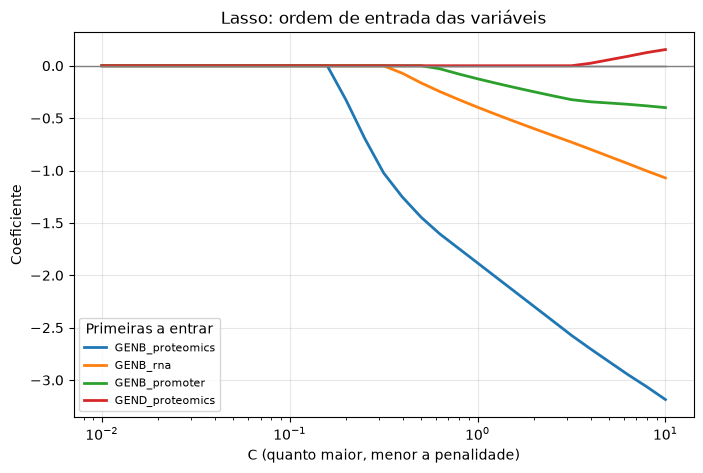

In [48]:
first_entries = entry_C.dropna().index[:6]

fig, ax = plt.subplots(figsize=(8, 5))
for variable in path.index:
    if variable not in first_entries:
        ax.plot(Cs, path.loc[variable], color="lightgray", linewidth=1)
for variable in first_entries:
    ax.plot(Cs, path.loc[variable], linewidth=2, label=variable)

ax.set_xscale("log")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Lasso: ordem de entrada das variáveis")
ax.set_xlabel("C (quanto maior, menor a penalidade)")
ax.set_ylabel("Coeficiente")
ax.legend(title="Primeiras a entrar", fontsize=8)
ax.grid(alpha=0.3)

# 8. Retorno à seleção <a id="retorno-selecao"></a>

## 8.1. Ablação

O KDD é iterativo, e esta seção volta à seleção com o que as seções 6 e 7 mostraram: os modelos separam os grupos, e as variáveis de GENB e GEND dominam a importância. A pergunta agora é o que acontece com o acerto quando essas variáveis saem da análise.

Retirar uma parte do sistema e medir o desempenho de novo, para ver o quanto ele dependia dela, se chama **ablação**. Uma versão sistemática é a seleção passo a passo para trás (*backward stepwise selection*), que começa com todas as variáveis e, a cada passo, retira a menos útil.

O formulário abaixo permite escolher as camadas, excluir genes e trocar o modelo. A célula lista as variáveis usadas e mede a acurácia com a mesma LOOCV da seção 6. Algumas perguntas para testar:

- O acerto muda sem as variáveis de GENB?
- E sem GENB e GEND ao mesmo tempo?
- Cada camada, sozinha, basta para separar os grupos?
- E os genótipos, sozinhos?

In [49]:
usar_atac = True  #@param {type:"boolean"}
usar_rna = True  #@param {type:"boolean"}
usar_proteomica = True  #@param {type:"boolean"}
usar_genotipos = True  #@param {type:"boolean"}
excluir_GENA = False  #@param {type:"boolean"}
excluir_GENB = False  #@param {type:"boolean"}
excluir_GENC = False  #@param {type:"boolean"}
excluir_GEND = False  #@param {type:"boolean"}
excluir_HK1 = False  #@param {type:"boolean"}
excluir_HK2 = False  #@param {type:"boolean"}
modelo_retorno = "REGRESSAO_LOGISTICA"  #@param ["REGRESSAO_LOGISTICA", "SVM", "RANDOM_FOREST"] {type:"string"}

layer_flags = [usar_atac, usar_rna, usar_proteomica, usar_genotipos]
gene_flags = [excluir_GENA, excluir_GENB, excluir_GENC, excluir_GEND, excluir_HK1, excluir_HK2]
selected_layers = [layer for layer, use in zip(all_layers, layer_flags) if use]
excluded_genes = [gene for gene, exclude in zip(genes, gene_flags) if exclude]

X_sel, y_sel = build_xy(df_norm, selected_layers, excluded_genes)
accuracy, matrix = evaluate(X_sel, y_sel, modelo_retorno)

print(f"Variáveis usadas ({X_sel.shape[1]}): {', '.join(X_sel.columns)}")
print(f"Acurácia ({modelo_retorno}): {accuracy:.0%}")

Variáveis usadas (22): GENA_promoter, GENB_promoter, GENC_promoter, GEND_promoter, HK1_promoter, HK2_promoter, GENA_rna, GENB_rna, GENC_rna, GEND_rna, HK1_rna, HK2_rna, GENA_proteomics, GENB_proteomics, GENC_proteomics, GEND_proteomics, HK1_proteomics, HK2_proteomics, rsToy1_GENA, rsToy2_GENB, rsToy3_GENC, rsToy4_REG
Acurácia (REGRESSAO_LOGISTICA): 100%


## 8.2. Redundância entre variáveis

A função `scenario_table` repete a avaliação para uma lista de cenários, cada um com uma combinação de camadas e genes excluídos, e para os três modelos. A tabela reúne numa só saída as perguntas do formulário acima, e o simulador da seção 9 usa a mesma função.

Três leituras ajudam a interpretar a tabela:

1. Se o acerto se mantém sem as variáveis de GENB, outras variáveis carregam a mesma diferença entre os grupos, e o modelo não depende de nenhum gene em particular.
2. Com a normalização CPM, retirar GENB e GEND pode não remover todo o sinal, porque o efeito de composição da seção 4.3 faz os outros genes de ATAC e RNA diferirem entre os grupos. Vale refazer a tabela com outra normalização.
3. Nos cenários sem sinal, a acurácia pode cair abaixo da linha de base, pelo efeito da LOOCV explicado na seção 6.8.

In [50]:
scenarios = {
    "Todas as variáveis": (all_layers, []),
    "Sem GENB": (all_layers, ["GENB"]),
    "Sem GEND": (all_layers, ["GEND"]),
    "Sem GENB e GEND": (all_layers, ["GENB", "GEND"]),
    "Só ATAC": (["ATAC"], []),
    "Só RNA": (["RNA"], []),
    "Só proteômica": (["PROTEOMICA"], []),
    "Só genótipos": (["GENOTIPOS"], []),
}

def scenario_table(data, scenarios):
    rows = []
    for scenario, (layers, excluded) in scenarios.items():
        X_s, y_s = build_xy(data, layers, excluded)
        row = {"scenario": scenario}
        for model_name in model_names:
            row[model_name], _ = evaluate(X_s, y_s, model_name)
        rows.append(row)
    return pd.DataFrame(rows).set_index("scenario")

In [51]:
scenario_table(df_norm, scenarios)

,REGRESSAO_LOGISTICA,SVM,RANDOM_FOREST
scenario,,,
Todas as variáveis,1.000000,1.000000,1.000000
Sem GENB,0.916667,0.833333,1.000000
Sem GEND,0.916667,0.916667,1.000000
Sem GENB e GEND,0.333333,0.083333,0.250000
Só ATAC,1.000000,0.916667,1.000000
Só RNA,1.000000,0.916667,1.000000
Só proteômica,1.000000,1.000000,1.000000
Só genótipos,0.250000,0.166667,0.416667


# 9. Simulador <a id="simulador"></a>

## 9.1. Simulação com resposta conhecida

O dataset original separa os grupos com facilidade e, por isso, não mostra em que situações um modelo falha. Para isso, o simulador gera datasets novos em que a resposta certa é conhecida de antemão: só GENB e GEND diferem entre os grupos, e nenhum outro gene nem SNP tem efeito. Assim é possível conferir se um método recupera a resposta certa, algo que no dado real não se sabe.

O objetivo da simulação é criar situações controladas, como pouco efeito, muito ruído ou muitas variáveis sem efeito, e observar como os passos das seções anteriores se comportam nelas. Ela não acrescenta amostras ao dataset original.

A função `reference_parameters` extrai do dataset normalizado, para cada variável contínua, três números em escala log2: a média dos controles, o log2 fold change e o desvio padrão combinado dos dois grupos (seção 4.4). O fold change é mantido só para GENB e GEND e zerado nos outros genes, para que a resposta certa seja conhecida. Para os SNPs, a referência é a frequência de um dos alelos em cada SNP.

In [52]:
effect_genes = ["GENB", "GEND"]

def reference_parameters(data):
    rows = []
    for layer in ["ATAC", "RNA", "PROTEOMICA"]:
        for col in layer_columns(data, layer):
            control = np.log2(data.loc[data["phenotype"] == 0, col])
            deficient = np.log2(data.loc[data["phenotype"] == 1, col])
            rows.append({
                "column": col,
                "layer": layer,
                "control_mean": control.mean(),
                "log2fc": deficient.mean() - control.mean() if col.split("_")[0] in effect_genes else 0.0,
                "std": np.sqrt((control.var() + deficient.var()) / 2),
            })
    return pd.DataFrame(rows)

In [53]:
reference = reference_parameters(df_norm)
snp_reference = df_norm[layer_columns(df_norm, "GENOTIPOS")].mean() / 2

reference

,column,layer,control_mean,log2fc,std
0,GENA_promoter,ATAC,9.400163,0.000000,0.083449
1,GENB_promoter,ATAC,9.700926,-2.444550,0.140415
2,GENC_promoter,ATAC,9.451348,0.000000,0.131471
3,GEND_promoter,ATAC,8.211292,0.834040,0.185633
4,HK1_promoter,ATAC,9.573212,0.000000,0.138224
5,HK2_promoter,ATAC,9.561409,0.000000,0.116968
6,GENA_rna,RNA,9.920155,0.000000,0.100426
7,GENB_rna,RNA,10.108372,-2.057443,0.160651
8,GENC_rna,RNA,9.620909,0.000000,0.106794
9,GEND_rna,RNA,7.992662,1.403331,0.116110


A função `simulate` gera cada valor, em escala log2, como uma soma de quatro partes:

$$\log_2 x_{ij} = \mu_j + e \, \delta_j \, g_i + r_j \, s_j \, \varepsilon_{ij} + b_j \, l_i,$$

em que:

- $\mu_j$ é a média dos controles na variável $j$, e $\delta_j$ é o seu log2 fold change;
- $g_i$ vale 1 se a amostra $i$ é `Deficient` e 0 se é controle, e $e$ é o multiplicador de efeito do formulário;
- $s_j$ é o desvio padrão da variável, $r_j$ é o multiplicador de ruído da camada e $\varepsilon_{ij}$ é um sorteio de uma normal padrão;
- $l_i$ vale 1 se a amostra está no lote B2, e $b_j$ é um deslocamento sorteado para cada variável, com desvio padrão dado pelo efeito do lote.

Depois, o valor volta para a escala linear, e ATAC e RNA são arredondados para contagens. Os genes nulos (`NULL...`) têm média sorteada dentro da faixa da camada e nenhum efeito. Os genótipos são sorteados como duas cópias independentes do cromossomo, e os SNPs nulos (`rsNull...`) têm frequência alélica sorteada entre 0,1 e 0,5.

In [54]:
def simulate(reference, snp_reference, n_per_group, effect, noise, n_null_genes, n_null_snps,
             batch_confounded, batch_shift, seed):
    rng = np.random.default_rng(seed)
    n = 2 * n_per_group
    phenotype = np.repeat([0, 1], n_per_group)

    if batch_confounded:
        batch = np.where(phenotype == 0, "B1", "B2")
    else:
        batch = np.tile(["B1", "B2"], n_per_group)
    in_b2 = batch == "B2"

    samples = pd.DataFrame({
        "sample_id": [f"S{i + 1:03d}" for i in range(n)],
        "group": np.where(phenotype == 1, "Deficient", "Control"),
        "phenotype": phenotype,
        "batch": batch,
    })

    null_rows = []
    for layer, suffix in [("ATAC", "_promoter"), ("RNA", "_rna"), ("PROTEOMICA", "_proteomics")]:
        layer_reference = reference[reference["layer"] == layer]
        for i in range(n_null_genes):
            null_rows.append({
                "column": f"NULL{i + 1:03d}{suffix}",
                "layer": layer,
                "control_mean": rng.uniform(layer_reference["control_mean"].min(), layer_reference["control_mean"].max()),
                "log2fc": 0.0,
                "std": layer_reference["std"].median(),
            })
    all_genes = pd.concat([reference, pd.DataFrame(null_rows)], ignore_index=True) if null_rows else reference

    values = {}
    for _, gene in all_genes.iterrows():
        log_values = (
            gene["control_mean"]
            + effect * gene["log2fc"] * phenotype
            + noise[gene["layer"]] * gene["std"] * rng.standard_normal(n)
            + rng.normal(0, batch_shift) * in_b2
        )
        linear_values = 2 ** log_values
        if gene["layer"] in ("ATAC", "RNA"):
            linear_values = np.round(linear_values)
        values[gene["column"]] = linear_values

    for snp, frequency in snp_reference.items():
        values[snp] = rng.binomial(2, frequency, n)
    for i in range(n_null_snps):
        values[f"rsNull{i + 1:03d}"] = rng.binomial(2, rng.uniform(0.1, 0.5), n)

    return pd.concat([samples, pd.DataFrame(values)], axis=1)

## 9.2. Sinal, ruído e tamanho amostral

Detectar uma diferença entre grupos depende do tamanho do efeito, da variabilidade das medições e do número de amostras. O **poder** de um teste é a probabilidade de ele detectar uma diferença que existe de fato. Poder, número de amostras, tamanho de efeito e nível de significância estão ligados: fixados três deles, o quarto fica determinado, e é esse cálculo que responde quantas réplicas um experimento precisa.

Na figura abaixo, os dois painéis têm a mesma variabilidade, com 6 amostras por grupo à esquerda e 60 à direita. Com mais amostras, a posição de cada grupo fica mais precisa, e a diferença entre eles fica mais fácil de detectar. A sobreposição entre os grupos, porém, continua a mesma, e é ela que limita o acerto de um classificador em cada amostra individual (seção 4.4).

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/comparesamplesize.png" alt="" width="800">
</div>

O formulário abaixo controla o simulador:

- `n_por_grupo`: número de amostras em cada grupo;
- `efeito`: multiplicador do fold change de GENB e GEND, em que 1 mantém o efeito medido no dataset original e 0 o remove;
- `ruido_atac`, `ruido_rna` e `ruido_proteomica`: multiplicadores do desvio padrão de cada camada;
- `genes_nulos` e `snps_nulos`: número de genes e SNPs sem efeito acrescentados, com cada gene nulo medido nas três camadas;
- `lote_confundido`: põe todos os controles no lote B1 e todos os `Deficient` no B2;
- `efeito_lote`: tamanho do deslocamento técnico do lote B2;
- `semente`: mantém o mesmo sorteio ou, se trocada, gera outro dataset com os mesmos parâmetros.

Com muitas amostras e muitas variáveis nulas, as células seguintes podem levar alguns minutos.

In [55]:
n_por_grupo = 6  #@param {type:"slider", min:3, max:50, step:1}
efeito = 1.0  #@param {type:"slider", min:0, max:2, step:0.1}
ruido_atac = 1.0  #@param {type:"slider", min:0.5, max:5, step:0.5}
ruido_rna = 1.0  #@param {type:"slider", min:0.5, max:5, step:0.5}
ruido_proteomica = 1.0  #@param {type:"slider", min:0.5, max:5, step:0.5}
genes_nulos = 0  #@param {type:"slider", min:0, max:300, step:10}
snps_nulos = 0  #@param {type:"slider", min:0, max:500, step:50}
lote_confundido = False  #@param {type:"boolean"}
efeito_lote = 0.0  #@param {type:"slider", min:0, max:1, step:0.1}
semente = 42  #@param {type:"integer"}

df_sim = simulate(
    reference, snp_reference,
    n_per_group=n_por_grupo,
    effect=efeito,
    noise={"ATAC": ruido_atac, "RNA": ruido_rna, "PROTEOMICA": ruido_proteomica},
    n_null_genes=genes_nulos,
    n_null_snps=snps_nulos,
    batch_confounded=lote_confundido,
    batch_shift=efeito_lote,
    seed=semente,
)

print(f"Amostras: {df_sim.shape[0]}, colunas: {df_sim.shape[1]}")
df_sim

Amostras: 12, colunas: 26


,sample_id,group,phenotype,batch,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,...,GENA_proteomics,GENB_proteomics,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,S001,Control,0,B1,688.0,929.0,735.0,322.0,663.0,806.0,...,1231.312855,1314.631131,1073.263340,480.686957,984.853194,1027.296440,1,0,2,1
1,S002,Control,0,B2,636.0,871.0,724.0,326.0,739.0,735.0,...,1329.445484,1275.038237,1149.855420,532.167322,1004.049646,1022.194685,1,0,0,1
2,S003,Control,0,B1,706.0,766.0,727.0,318.0,728.0,728.0,...,1163.519945,1346.894637,1114.999084,496.855445,1049.587275,929.343908,0,0,0,2
3,S004,Control,0,B2,713.0,863.0,728.0,272.0,717.0,810.0,...,1093.927461,1287.789142,1172.511927,509.822847,969.312795,1015.570879,1,1,0,2
4,S005,Control,0,B1,604.0,758.0,851.0,305.0,742.0,744.0,...,1115.773942,1239.301651,1102.630482,504.511395,1017.129377,1026.190061,1,1,0,0
5,S006,Control,0,B2,627.0,907.0,675.0,301.0,879.0,681.0,...,1140.112498,1236.075925,1034.317559,521.512140,998.718104,1219.862147,1,0,0,0
6,S007,Deficient,1,B1,681.0,152.0,668.0,543.0,701.0,689.0,...,1473.768455,362.940596,1027.587175,1209.084427,1004.279482,1162.249360,1,0,0,0
7,S008,Deficient,1,B2,663.0,150.0,650.0,591.0,836.0,701.0,...,1130.293232,389.275169,1178.663361,1108.215579,1052.827037,945.709101,0,1,0,0
8,S009,Deficient,1,B1,675.0,143.0,740.0,544.0,648.0,787.0,...,1312.306553,362.712986,1182.564967,1149.532454,1035.611145,986.998997,0,0,0,1
9,S010,Deficient,1,B2,643.0,172.0,776.0,577.0,738.0,764.0,...,1122.033162,357.714577,1084.606797,961.886152,1065.403113,903.117382,0,1,1,1


A tabela cruzada mostra como lote e grupo ficaram distribuídos no dataset simulado, e a tabela de cenários repete sobre ele a ablação da seção 8. Algumas experiências:

- reduzir o `efeito` até o acerto cair e, depois, aumentar `n_por_grupo`;
- aumentar o ruído de uma camada e observar se as outras sustentam o acerto;
- zerar o `efeito`, marcar `lote_confundido` e dar um `efeito_lote` maior que zero, para ver se o modelo acerta sem nenhuma diferença biológica entre os grupos (seção 4.2);
- zerar o `efeito` com o lote equilibrado e comparar a acurácia com a linha de base (seção 6.8).

In [56]:
pd.crosstab(df_sim["batch"], df_sim["group"], margins=True, margins_name="Total")

group,Control,Deficient,Total
batch,,,
B1,3,3,6
B2,3,3,6
Total,6,6,12


In [57]:
scenario_table(df_sim, scenarios)

,REGRESSAO_LOGISTICA,SVM,RANDOM_FOREST
scenario,,,
Todas as variáveis,1.000000,1.000000,1.000000
Sem GENB,1.000000,0.833333,1.000000
Sem GEND,1.000000,0.833333,1.000000
Sem GENB e GEND,0.416667,0.000000,0.333333
Só ATAC,1.000000,1.000000,1.000000
Só RNA,1.000000,1.000000,1.000000
Só proteômica,1.000000,0.916667,1.000000
Só genótipos,0.333333,0.000000,0.250000


## 9.3. Falsos positivos em alta dimensão

Quando há muitas variáveis sem efeito, algumas parecem associadas ao rótulo só por acaso, e o risco cresce com o número de variáveis (seções 4.6 e 6.6).

O gráfico abaixo treina Random Forests no dataset simulado e mostra as quinze variáveis mais importantes, coloridas pela resposta conhecida: com efeito (GENB e GEND), sem efeito (os outros genes e os SNPs originais) e nulas (as acrescentadas pelo simulador). Com muitos genes e SNPs nulos e pouco efeito, vale observar se variáveis nulas aparecem entre as mais importantes.

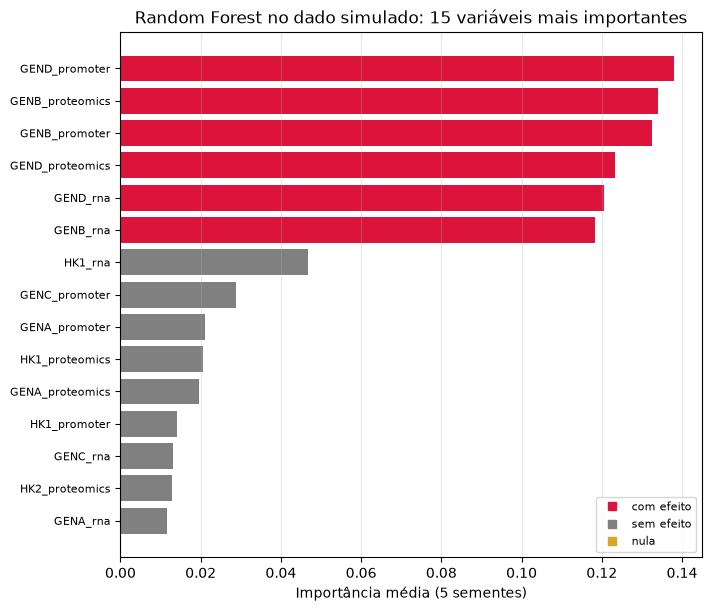

In [58]:
X_sim, y_sim = build_xy(df_sim, all_layers)
importances_sim = rf_importances(X_sim, y_sim, seeds=range(5))
top_sim = importances_sim.mean(axis=1).sort_values().tail(15)

def variable_kind(variable):
    if variable.startswith(("NULL", "rsNull")):
        return "nula"
    if variable.split("_")[0] in effect_genes:
        return "com efeito"
    return "sem efeito"

kind_colors = {"com efeito": "crimson", "sem efeito": "gray", "nula": "goldenrod"}
colors = [kind_colors[variable_kind(v)] for v in top_sim.index]

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.barh(top_sim.index, top_sim.values, color=colors)
handles = [plt.Line2D([], [], marker="s", linestyle="", color=c, label=k) for k, c in kind_colors.items()]
ax.legend(handles=handles, fontsize=8)
ax.set_title("Random Forest no dado simulado: 15 variáveis mais importantes")
ax.set_xlabel("Importância média (5 sementes)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)

Nos SNPs, a célula abaixo testa a associação de cada um com o fenótipo. Cada SNP vira uma tabela 2 × 2 de contagens, com portadores e não portadores do alelo nas linhas e controles e `Deficient` nas colunas. O teste exato de Fisher calcula o p-valor dessa tabela sem recorrer a aproximações, o que o torna adequado a contagens pequenas. Agrupar em portador e não portador supõe um modelo dominante, diferente da codificação aditiva (0, 1 e 2) usada no $X$ (seção 5.1).

A célula conta quantos SNPs ficam abaixo de 0,05 antes e depois da correção de Benjamini-Hochberg (seção 4.6). Como nenhum SNP tem efeito, todo SNP abaixo do limite é um falso positivo. A figura abaixo mostra a manchete que um estudo com muitos testes e sem correção poderia produzir.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/xkcdmulttest-newspapertitle.png" alt="" width="400">
</div>

In [59]:
rows = []
for snp in layer_columns(df_sim, "GENOTIPOS"):
    carrier = df_sim[snp] > 0
    deficient = df_sim["phenotype"] == 1
    table = [
        [(carrier & deficient).sum(), (carrier & ~deficient).sum()],
        [(~carrier & deficient).sum(), (~carrier & ~deficient).sum()],
    ]
    rows.append({"snp": snp, "p": stats.fisher_exact(table).pvalue})

df_snps = pd.DataFrame(rows)
df_snps["p_corrected"] = stats.false_discovery_control(df_snps["p"], method="bh")

print(f"SNPs testados: {len(df_snps)}")
print(f"SNPs com p < 0,05 sem correção: {(df_snps['p'] < 0.05).sum()}")
print(f"SNPs com p < 0,05 depois da correção BH: {(df_snps['p_corrected'] < 0.05).sum()}")
df_snps.sort_values("p").head(10)

SNPs testados: 4
SNPs com p < 0,05 sem correção: 0
SNPs com p < 0,05 depois da correção BH: 0


,snp,p,p_corrected
0,rsToy1_GENA,0.545455,1.0
1,rsToy2_GENB,1.000000,1.0
2,rsToy3_GENC,1.000000,1.0
3,rsToy4_REG,1.000000,1.0


# 10. Conclusão <a id="conclusao"></a>

<!-- Pendente: confirmar com a Sintia a leitura de ATAC_GEND, que também muda no grupo Deficient e não aparece no gabarito. -->
Os modelos das seções 6 e 7 separaram controles e `Deficient` com facilidade e apontaram as variáveis de GENB e GEND como as mais importantes. A variável preferida, porém, mudou com o método e com a semente, e retirar GENB da análise quase não mudou o acerto (seção 8).

O dataset foi montado com um mecanismo conhecido:

- a acessibilidade do promotor de GENB cai no grupo `Deficient`, e essa é a causa do fenótipo;
- o RNA e a proteína de GENB caem como consequência dessa primeira mudança;
- o RNA e a proteína de GEND sobem como resposta compensatória;
- GENA e GENC, os parceiros de GENB no complexo, ficam praticamente estáveis;
- os genótipos não têm papel causal e estão no dataset para testar o controle de falsos positivos.

Nenhum método apontou o promotor de GENB de forma consistente. A regressão logística distribuiu o peso entre as variáveis de GENB e GEND, o Random Forest alternou entre elas conforme a semente, e o lasso escolheu primeiro a proteína de GENB. GEND, que apenas responde ao problema, separou os grupos tão bem quanto GENB.

Esse é o resultado central da aula: **um modelo pode prever perfeitamente usando um marcador que não é a causa**. O aprendizado supervisionado encontra variáveis associadas ao rótulo, e consequências e compensações se associam ao fenótipo tanto quanto a causa. Nada na tabela $X$ indica qual camada vem antes (seção 3.2).

Para ir da associação à causa, é preciso outro tipo de evidência, como intervir no sistema (silenciar GENB, por exemplo) ou acompanhar a ordem das mudanças no tempo.

Algumas lições valem para qualquer análise de dados ômicos com aprendizado de máquina:

1. Um acerto alto mostra que as variáveis separam os grupos. Explicar o fenótipo exige outro tipo de evidência.
2. A importância de variáveis depende do método e, nos métodos com sorteio, da semente. Variáveis redundantes trocam de lugar entre si.
3. Escolhas do pré-processamento, como a normalização e o log, mudam o que parece significativo e o que o modelo usa.
4. O desempenho só vale quando medido em amostras que ficaram fora do treino, com o pré-processamento ajustado apenas no treino.
5. Com muitas variáveis e poucas amostras, associações aparecem por acaso. A correção para testes múltiplos e a simulação com resposta conhecida ajudam a separar sinal de acaso.

# Referências <a id="referencias"></a>

- FAYYAD, U.; PIATETSKY-SHAPIRO, G.; SMYTH, P. From data mining to knowledge discovery in databases. **AI Magazine**, v. 17, n. 3, p. 37-54, 1996.

- GÉRON, A. **Mãos à obra**: aprendizado de máquina com Scikit-Learn & TensorFlow: conceitos, ferramentas e técnicas para a construção de sistemas inteligentes. Tradução de Rafael Contatori. Rio de Janeiro: Alta Books, 2019.

- HOLMES, S.; HUBER, W. **Modern statistics for modern biology**. Cambridge: Cambridge University Press, 2019. Disponível em: https://www.huber.embl.de/msmb/. Acesso em: 30 set. 2026.

- JAMES, G.; WITTEN, D.; HASTIE, T.; TIBSHIRANI, R.; TAYLOR, J. **An introduction to statistical learning**: with applications in Python. Cham: Springer, 2023. Disponível em: https://www.statlearning.com/. Acesso em: 30 set. 2026.